### Load Necessary Libraries

In [ ]:
# Random seed for reproducibility
from numpy.random import seed
seed(123)

# Data manipulation and numerical libraries
import pandas as pd
import numpy as np

# Statistical and machine learning libraries
from scipy.stats import shapiro
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error as mape
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# Time series analysis libraries
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.deterministic import DeterministicProcess
from statsmodels.tsa.statespace.structural import UnobservedComponents
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Visualization libraries
from matplotlib import pyplot as plt
from matplotlib.pyplot import figure
import seaborn as sns
import plotly.express as px

# Datetime library
from datetime import datetime, timedelta


### Functions

In [ ]:
def acf_pacf(y, lags):
    """
    Plot of acf e pacf, 0-lag not included
    """
    fig, ax = plt.subplots(1, 2, figsize=(20,8))
    plot_acf(y, lags=lags, ax=ax[0], zero=False, auto_ylims=True, alpha=.05)
    plot_pacf(y, lags=lags, ax=ax[1], zero=False, auto_ylims=True, alpha=.05)
    plt.show()

In [ ]:

# Function to calculate Mean Absolute Percentage Error (MAPE) with zero-value handling
def calculate_mape(actual, predicted):
    # Filter out zero values from the actual array to avoid division by zero
    mask = actual != 0
    actual_filtered = actual[mask]
    predicted_filtered = predicted[mask]

    mape = np.mean(np.abs((actual_filtered - predicted_filtered) / actual_filtered)) * 100
    return mape


In [ ]:

# Function to calculate Mean Absolute Error (MAE)
def calculate_mae(actual, predicted):
    mae = np.mean(np.abs(actual - predicted))
    return mae

### Load Data: Load your time series data into a pandas DataFrame.

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# file_path = '/content/drive/My Drive/train.csv'
# df = pd.read_csv(file_path)

In [ ]:
df = pd.read_csv('train.csv')

In [ ]:
df

,date,weekday,ave_days
0,2007-01-04,Thursday,0.179487
1,2007-01-05,Friday,0.500000
2,2007-01-06,Saturday,NaN
3,2007-01-07,Sunday,NaN
4,2007-01-08,Monday,3.521739
...,...,...,...
3004,2015-03-27,Friday,38.580756
3005,2015-03-28,Saturday,1.040000
3006,2015-03-29,Sunday,42.000000
3007,2015-03-30,Monday,63.477124


In [ ]:
df.shape, df.columns, df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3009 entries, 0 to 3008
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      3009 non-null   object 
 1   weekday   3009 non-null   object 
 2   ave_days  2807 non-null   float64
dtypes: float64(1), object(2)
memory usage: 70.6+ KB


((3009, 3), Index(['date', 'weekday', 'ave_days'], dtype='object'), None)

### Preprocessing

In [ ]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

### Duplicates

In [ ]:
print(sum(df.duplicated()))

0


### NA values

In [ ]:
df.isnull().sum()

date          0
weekday       0
ave_days    202
dtype: int64

In [ ]:

df['week'] = df['date'].dt.isocalendar().week

weekly_means = df.groupby('week')['ave_days'].mean()
df['ave_days'] = df['ave_days'].fillna(df['week'].map(weekly_means))

# Drop the 'week' column if you don't need it anymore
df.drop(columns=['week'], inplace=True)


In [ ]:
df.isnull().sum()

date        0
weekday     0
ave_days    0
dtype: int64

### Visualize the Original Time Series Data

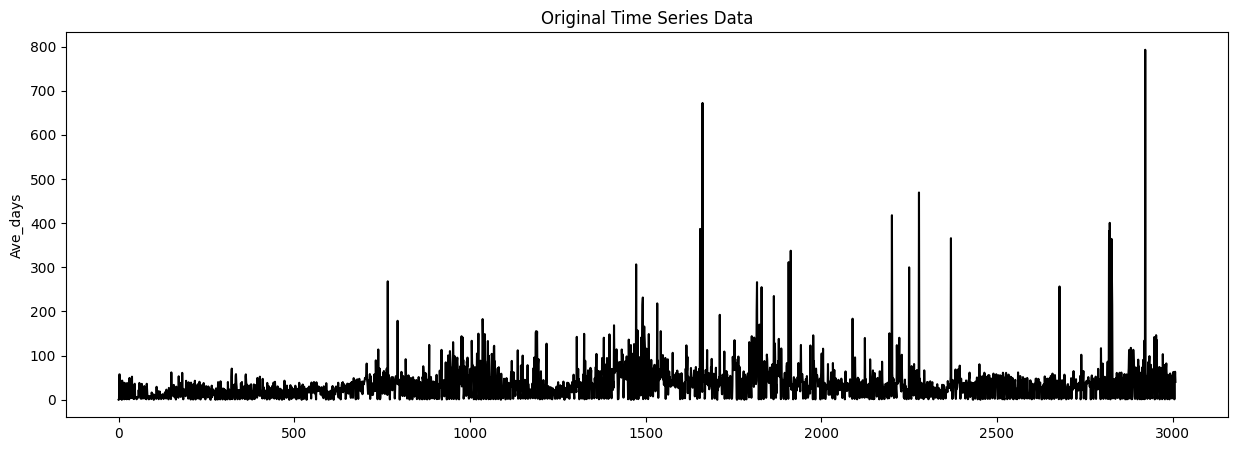

In [ ]:

# Plot original time series data
plt.figure(figsize=(15, 5))
plt.plot(df['ave_days'], color='black')
plt.title('Original Time Series Data')
plt.ylabel('Ave_days')
plt.show()


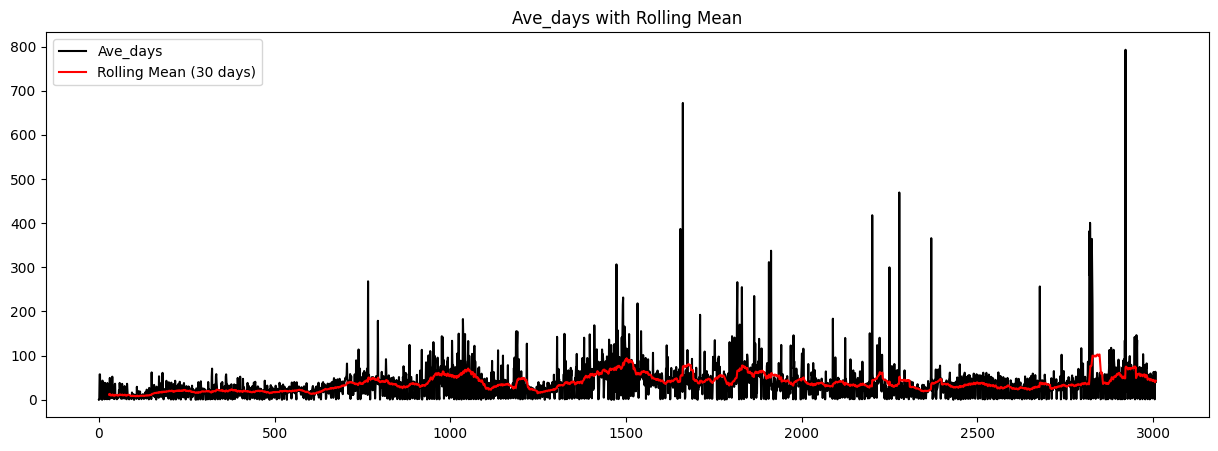

In [ ]:
# Calculate the rolling mean
rolling_mean = df['ave_days'].rolling(window=30).mean()  # Adjust the window size as needed

# Plot the time series data and the rolling mean
plt.figure(figsize=(15, 5))
plt.plot(df['ave_days'], color='black', label='Ave_days')
plt.plot(rolling_mean, color='red', label='Rolling Mean (30 days)')  # Adjust the label and color as needed
plt.title('Ave_days with Rolling Mean')
plt.legend()  # Add legend to the plot
plt.show()

### Time plot : The obvious graph to start with is the time plot. That is, the observations are plotted against the time they were observed, with consecutive observations joined by lines.

In [ ]:
dfa = df.copy()
dfa.set_index('date', inplace = True)
dfa

,weekday,ave_days
date,,
2007-01-04,Thursday,0.179487
2007-01-05,Friday,0.500000
2007-01-06,Saturday,57.539966
2007-01-07,Sunday,57.539966
2007-01-08,Monday,3.521739
...,...,...
2015-03-27,Friday,38.580756
2015-03-28,Saturday,1.040000
2015-03-29,Sunday,42.000000


<ipython-input-15-0ef6148bc636>:4: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn")


Text(0.5, 0, 'Date')

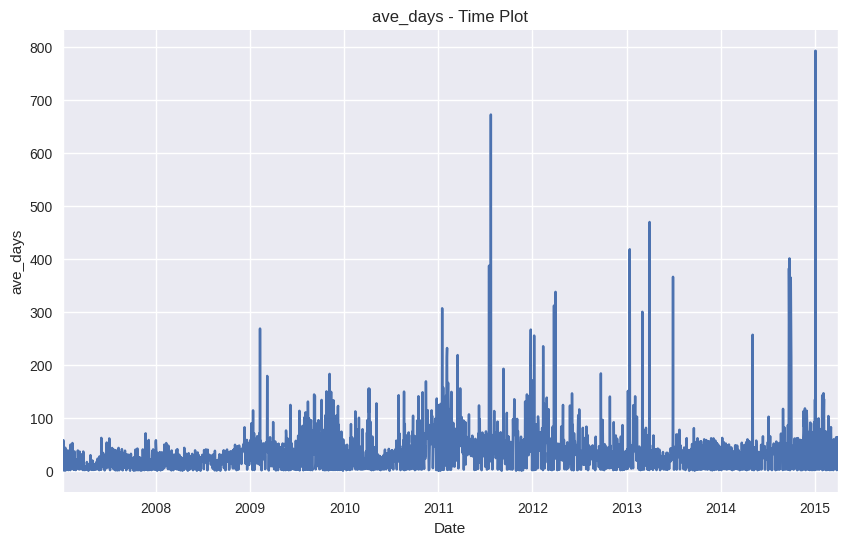

In [ ]:
# import matplotlib.pyplot as plt

# Set pyplot style
plt.style.use("seaborn")

# Plot
dfa['ave_days'].plot(title='ave_days - Time Plot', figsize=(10,6))
plt.ylabel('ave_days')
plt.xlabel('Date')

# As we could expect, the pattern shows yearly seasonality.
# Focusing on a single year, it seems that more pattern emerges.
# The series exhibits a clear increasing/decreasing trend over the years,

In [ ]:
df

,date,weekday,ave_days
0,2007-01-04,Thursday,0.179487
1,2007-01-05,Friday,0.500000
2,2007-01-06,Saturday,57.539966
3,2007-01-07,Sunday,57.539966
4,2007-01-08,Monday,3.521739
...,...,...,...
3004,2015-03-27,Friday,38.580756
3005,2015-03-28,Saturday,1.040000
3006,2015-03-29,Sunday,42.000000
3007,2015-03-30,Monday,63.477124


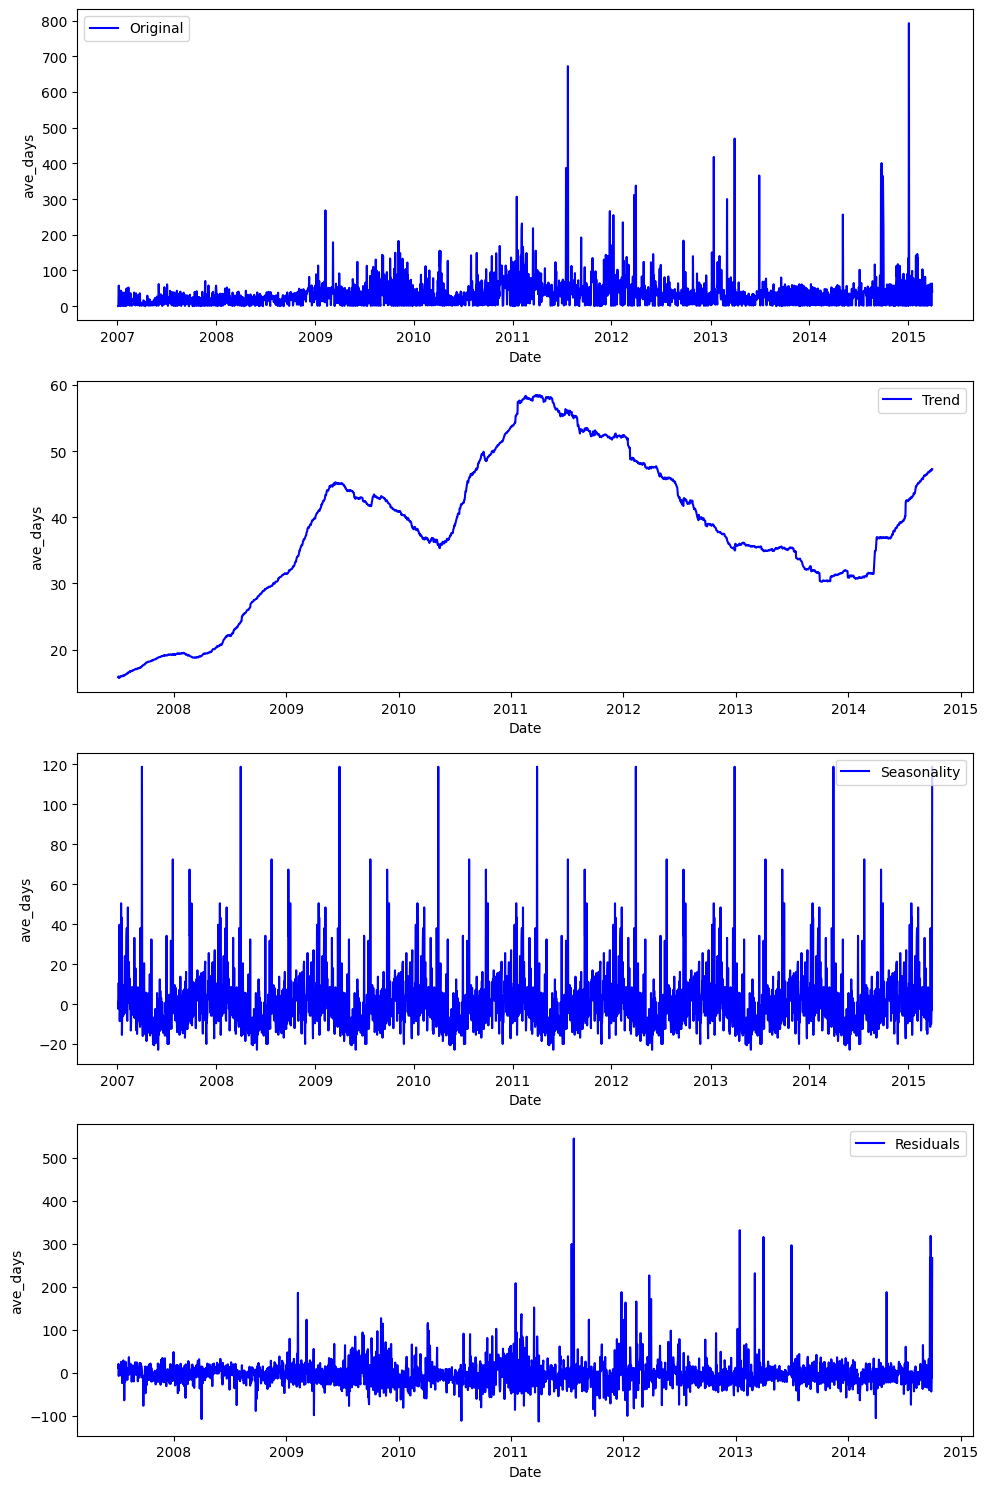

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set the 'date' column as the index
dfb = df.copy()
dfb.set_index('date', inplace=True)

# Perform seasonal decomposition
decomposition = seasonal_decompose(dfb['ave_days'], period=365)

# Gather the trend, seasonality, and residuals
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Plot gathered statistics
plt.figure(figsize=(10, 15))

plt.subplot(411)
plt.plot(dfb['ave_days'], label='Original', color='blue')
plt.legend(loc='best')
plt.xlabel('Date')
plt.ylabel('ave_days')

plt.subplot(412)
plt.plot(trend, label='Trend', color='blue')
plt.legend(loc='best')
plt.xlabel('Date')
plt.ylabel('ave_days')

plt.subplot(413)
plt.plot(seasonal, label='Seasonality', color='blue')
plt.legend(loc='best')
plt.xlabel('Date')
plt.ylabel('ave_days')

plt.subplot(414)
plt.plot(residual, label='Residuals', color='blue')
plt.legend(loc='best')
plt.xlabel('Date')
plt.ylabel('ave_days')

plt.tight_layout()
plt.show()

In [ ]:
# plt.tight_layout()
# plt.savefig('decomposition_plots.jpg', format='jpg')
# plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
# from google.colab import files

# # Save the plot as a JPEG file
# plt.savefig('decomposition_plots.jpg', format='jpg')
# plt.show()

# # Download the file to your local drive
# files.download('decomposition_plots.jpg')


<Figure size 640x480 with 0 Axes>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Some time-series models, such as such as ARIMA, assume that the underlying data is stationary. Stationarity describes that the time-series :
has constant mean and mean is not time-dependent,
constant variance and variance is not time-dependent,
constant covariance and covariance is not time-dependent.

### To verify the stationarity in variance of the time series, check the Box-Cox graph to observe whether there is a relationship between the mean and the standard deviation.

In [ ]:
newdf = df.copy()

In [ ]:
newdf.set_index('date', inplace = True)

In [ ]:
dfArima = newdf[['ave_days']]

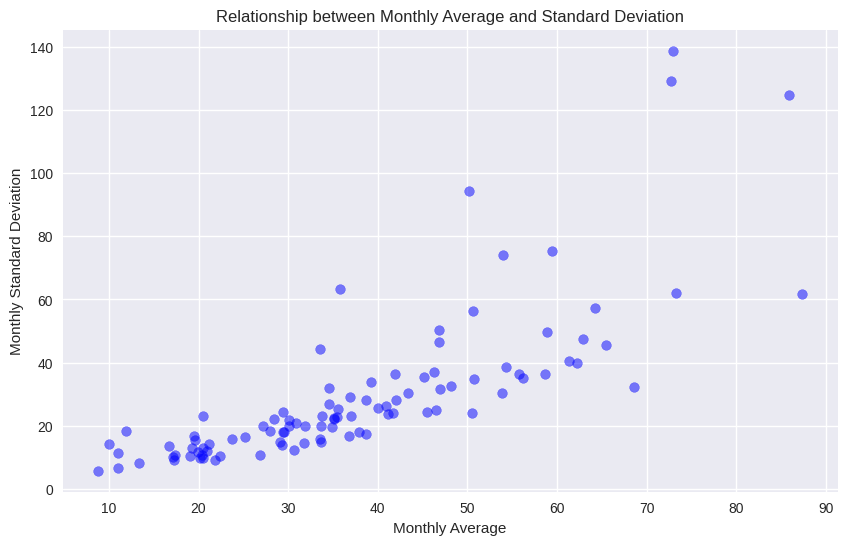

In [ ]:
# Convert the index to datetime if it's not already in datetime format
# df.index = pd.to_datetime(df.index)

# Resample the DataFrame to calculate monthly average values and standard deviations
monthly_avg = dfArima['ave_days'].resample('M').mean()
monthly_std = dfArima['ave_days'].resample('M').std()

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(monthly_avg, monthly_std, color='blue', alpha=0.5)
plt.title('Relationship between Monthly Average and Standard Deviation')
plt.xlabel('Monthly Average')
plt.ylabel('Monthly Standard Deviation')
plt.grid(True)
plt.show()

### Handling Outliers

In [ ]:
import pandas as pd

# Calculate quartiles and IQR
Q1 = df['ave_days'].quantile(0.25)
Q3 = df['ave_days'].quantile(0.75)
IQR = Q3 - Q1

# Determine the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outliers
outliers = df[(df['ave_days'] < lower_bound) | (df['ave_days'] > upper_bound)]

# Calculate weekly means for non-outlier data
weekly_means = df[~df.index.isin(outliers.index)].groupby(df['date'].dt.isocalendar().week)['ave_days'].mean()

# Replace outliers with the mean of the corresponding week
for index, row in outliers.iterrows():
    week_mean = weekly_means[row['date'].week]
    df.at[index, 'ave_days'] = week_mean

In [ ]:
dfAArima = df[['date','ave_days']]
dfAArima.set_index('date', inplace=True)

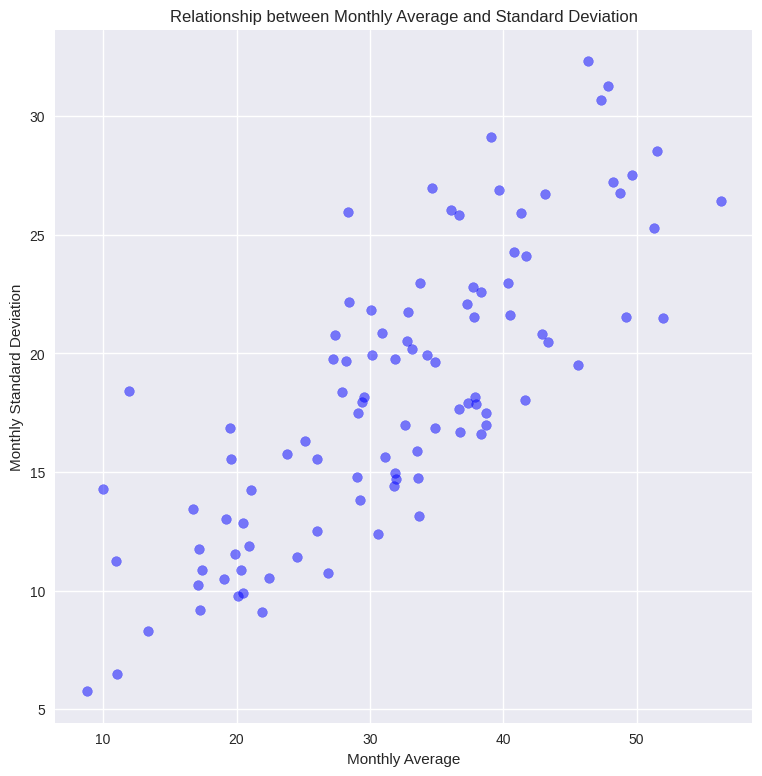

In [ ]:
# Convert the index to datetime if it's not already in datetime format
# df.index = pd.to_datetime(df.index)

# Resample the DataFrame to calculate monthly average values and standard deviations
monthly_avg = dfAArima['ave_days'].resample('M').mean()
monthly_std = dfAArima['ave_days'].resample('M').std()

# Create scatter plot
plt.figure(figsize=(9, 9))
plt.scatter(monthly_avg, monthly_std, color='blue', alpha=0.5)
plt.title('Relationship between Monthly Average and Standard Deviation')
plt.xlabel('Monthly Average')
plt.ylabel('Monthly Standard Deviation')
plt.grid(True)
plt.show()

In [ ]:
dfAArima.head()

,ave_days
date,
2007-01-04,0.179487
2007-01-05,0.500000
2007-01-06,57.539966
2007-01-07,57.539966
2007-01-08,3.521739


In [ ]:
# Summary statistics

summary_stats = dfAArima.describe()
summary_stats


,ave_days
count,3009.000000
mean,31.782398
std,21.691723
min,0.000000
25%,15.068966
50%,31.218638
75%,44.665615
max,97.186992


In [ ]:
df

,date,weekday,ave_days
0,2007-01-04,Thursday,0.179487
1,2007-01-05,Friday,0.500000
2,2007-01-06,Saturday,57.539966
3,2007-01-07,Sunday,57.539966
4,2007-01-08,Monday,3.521739
...,...,...,...
3004,2015-03-27,Friday,38.580756
3005,2015-03-28,Saturday,1.040000
3006,2015-03-29,Sunday,42.000000
3007,2015-03-30,Monday,63.477124


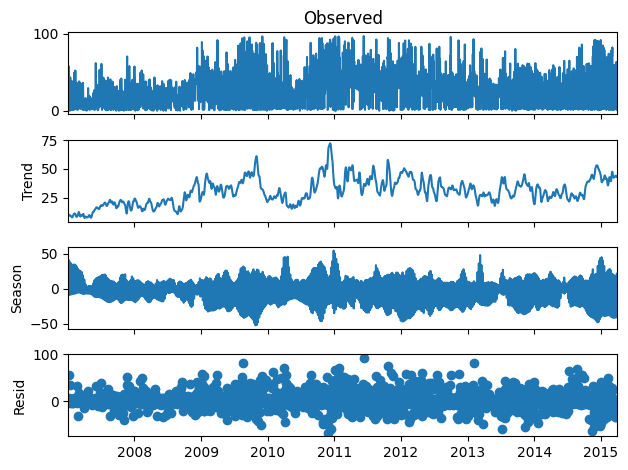

In [ ]:
from statsmodels.tsa.seasonal import STL

dfAArimaa = dfAArima.copy()
dfAArimaa.asfreq('MS') # Set frequency
# Set robust to True to handle outliers
res = STL(dfAArimaa, robust = True).fit()
res.plot()
plt.show()


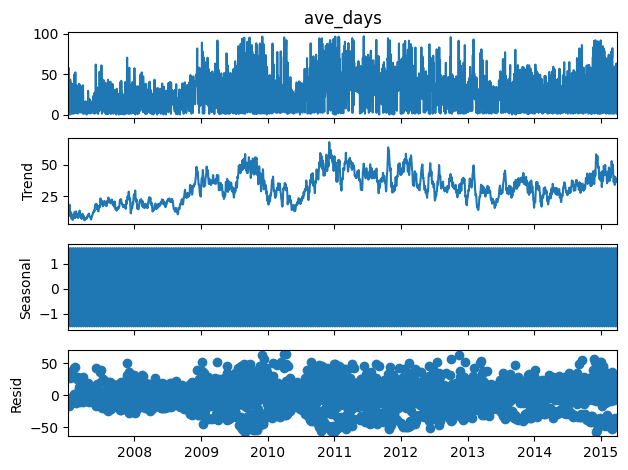

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the time series
result = seasonal_decompose(dfAArima['ave_days'], model='additive', period=12)  # Adjust the period as necessary

# Plot the decomposition
result.plot()
plt.show()


### Resampling can provide additional information on the data. There are two types of resampling:

Upsampling is when the frequency of samples is increased (e.g. days to hours)
Downsampling is when the frequency of samples is decreased (e.g. days to weeks)
In this example, we will do some downsampling with the .resample() function (similar to groupby and aggregate as mean).

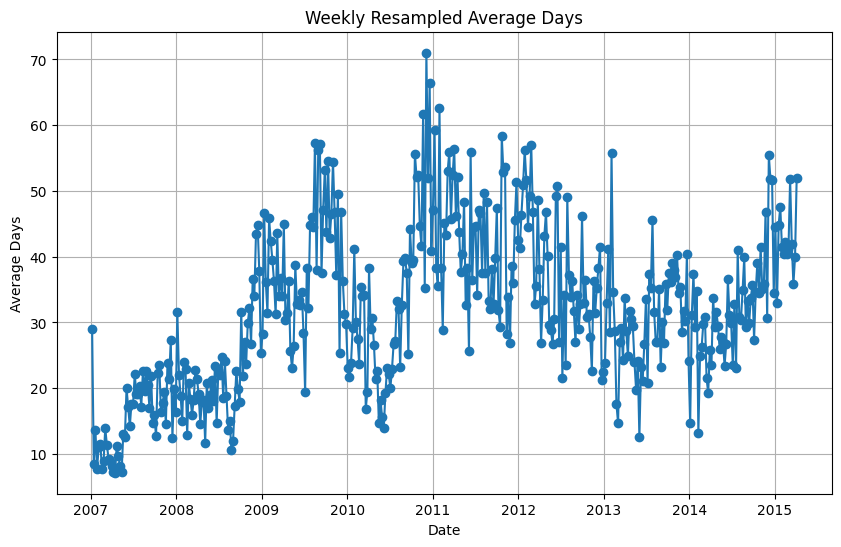

In [ ]:
# Perform resampling on a weekly basis and calculate the mean for each week
df_resampled_weekly = dfAArimaa.resample('W').mean()

# Plotting the resampled data
plt.figure(figsize=(10, 6))
plt.plot(df_resampled_weekly.index, df_resampled_weekly['ave_days'], marker='o', linestyle='-')
plt.title('Weekly Resampled Average Days')
plt.xlabel('Date')
plt.ylabel('Average Days')
plt.grid(True)
plt.show()

In [ ]:
df_resampled_weekly

,ave_days
date,
2007-01-07,28.939855
2007-01-14,8.426236
2007-01-21,13.654613
2007-01-28,7.751357
2007-02-04,11.007472
...,...
2015-03-08,51.826295
2015-03-15,41.986786
2015-03-22,35.816996


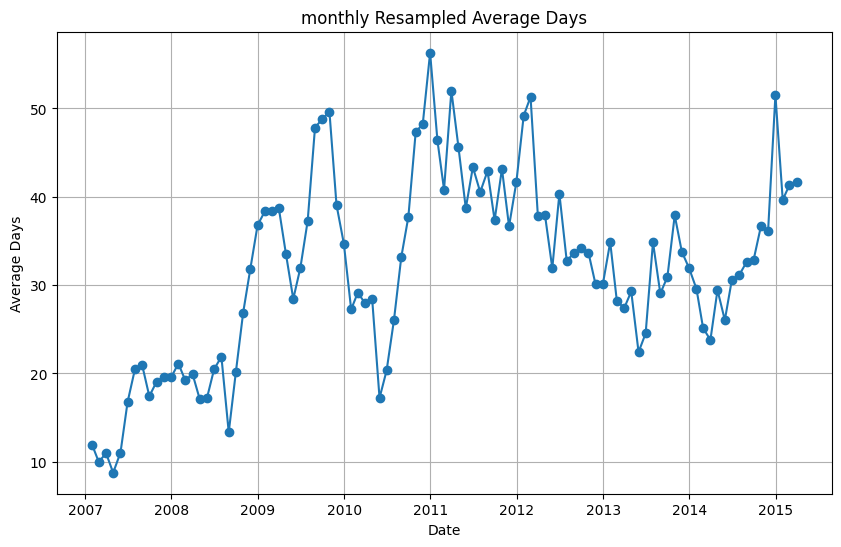

In [ ]:
# Perform resampling on a weekly basis and calculate the mean for each week
df_resampled_monthly = dfAArimaa.resample('M').mean()

# Plotting the resampled data
plt.figure(figsize=(10, 6))
plt.plot(df_resampled_monthly.index, df_resampled_monthly['ave_days'], marker='o', linestyle='-')
plt.title('monthly Resampled Average Days')
plt.xlabel('Date')
plt.ylabel('Average Days')
plt.grid(True)
plt.show()

In [ ]:
# from statsmodels.tsa.seasonal import seasonal_decompose

# # Decompose the time series
# result = seasonal_decompose(dfAArima['ave_days'], model='multiplicative', period=12)  # Adjust the period as necessary

# # Plot the decomposition
# result.plot()
# plt.show()

### Methods to Check Stationarity : Augmented Dickey-Fuller (ADF) Test or Unit Root Test

In [ ]:
# ADF Test
# Function to print out results in customised manner
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)
# Call the function and run the test

adf_test(dfAArima['ave_days'])

Results of Dickey-Fuller Test:
Test Statistic                   -3.623802
p-value                           0.005322
#Lags Used                       27.000000
Number of Observations Used    2981.000000
Critical Value (1%)              -3.432546
Critical Value (5%)              -2.862510
Critical Value (10%)             -2.567286
dtype: float64


## Splitting the data into the training and validation part

In [ ]:
df

,date,weekday,ave_days
0,2007-01-04,Thursday,0.179487
1,2007-01-05,Friday,0.500000
2,2007-01-06,Saturday,57.539966
3,2007-01-07,Sunday,57.539966
4,2007-01-08,Monday,3.521739
...,...,...,...
3004,2015-03-27,Friday,38.580756
3005,2015-03-28,Saturday,1.040000
3006,2015-03-29,Sunday,42.000000
3007,2015-03-30,Monday,63.477124


In [ ]:
dff = df.copy()
dff

,date,weekday,ave_days
0,2007-01-04,Thursday,0.179487
1,2007-01-05,Friday,0.500000
2,2007-01-06,Saturday,57.539966
3,2007-01-07,Sunday,57.539966
4,2007-01-08,Monday,3.521739
...,...,...,...
3004,2015-03-27,Friday,38.580756
3005,2015-03-28,Saturday,1.040000
3006,2015-03-29,Sunday,42.000000
3007,2015-03-30,Monday,63.477124


In [ ]:
dff.set_index('date', inplace = True)
dff

,weekday,ave_days
date,,
2007-01-04,Thursday,0.179487
2007-01-05,Friday,0.500000
2007-01-06,Saturday,57.539966
2007-01-07,Sunday,57.539966
2007-01-08,Monday,3.521739
...,...,...
2015-03-27,Friday,38.580756
2015-03-28,Saturday,1.040000
2015-03-29,Sunday,42.000000


In [ ]:
df2 = df.copy()
df2.index = pd.to_datetime(df2.date)
# Split the data into training and validation sets based on the date column
train_data = df2[df2['date'] < pd.to_datetime('2013-03-31')] # 2013-08-07
val_data = df2[df2['date'] >= pd.to_datetime('2013-03-31')]

In [ ]:
train_data

,date,weekday,ave_days
date,,,
2007-01-04,2007-01-04,Thursday,0.179487
2007-01-05,2007-01-05,Friday,0.500000
2007-01-06,2007-01-06,Saturday,57.539966
2007-01-07,2007-01-07,Sunday,57.539966
2007-01-08,2007-01-08,Monday,3.521739
...,...,...,...
2013-03-26,2013-03-26,Tuesday,25.945813
2013-03-27,2013-03-27,Wednesday,31.072948
2013-03-28,2013-03-28,Thursday,44.032738


In [ ]:
val_data

,date,weekday,ave_days
date,,,
2013-03-31,2013-03-31,Sunday,32.854278
2013-04-01,2013-04-01,Monday,34.233516
2013-04-02,2013-04-02,Tuesday,48.228261
2013-04-03,2013-04-03,Wednesday,25.140468
2013-04-04,2013-04-04,Thursday,31.764085
...,...,...,...
2015-03-27,2015-03-27,Friday,38.580756
2015-03-28,2015-03-28,Saturday,1.040000
2015-03-29,2015-03-29,Sunday,42.000000


In [ ]:
train_data_df = train_data['ave_days']
val_data_df = val_data['ave_days']

In [ ]:
train_data_df

date
2007-01-04     0.179487
2007-01-05     0.500000
2007-01-06    57.539966
2007-01-07    57.539966
2007-01-08     3.521739
                ...    
2013-03-26    25.945813
2013-03-27    31.072948
2013-03-28    44.032738
2013-03-29    33.436364
2013-03-30     1.244898
Name: ave_days, Length: 2278, dtype: float64

In [ ]:
val_data_df

date
2013-03-31    32.854278
2013-04-01    34.233516
2013-04-02    48.228261
2013-04-03    25.140468
2013-04-04    31.764085
                ...    
2015-03-27    38.580756
2015-03-28     1.040000
2015-03-29    42.000000
2015-03-30    63.477124
2015-03-31    40.496689
Name: ave_days, Length: 731, dtype: float64

### Visualize Train and Validation Data

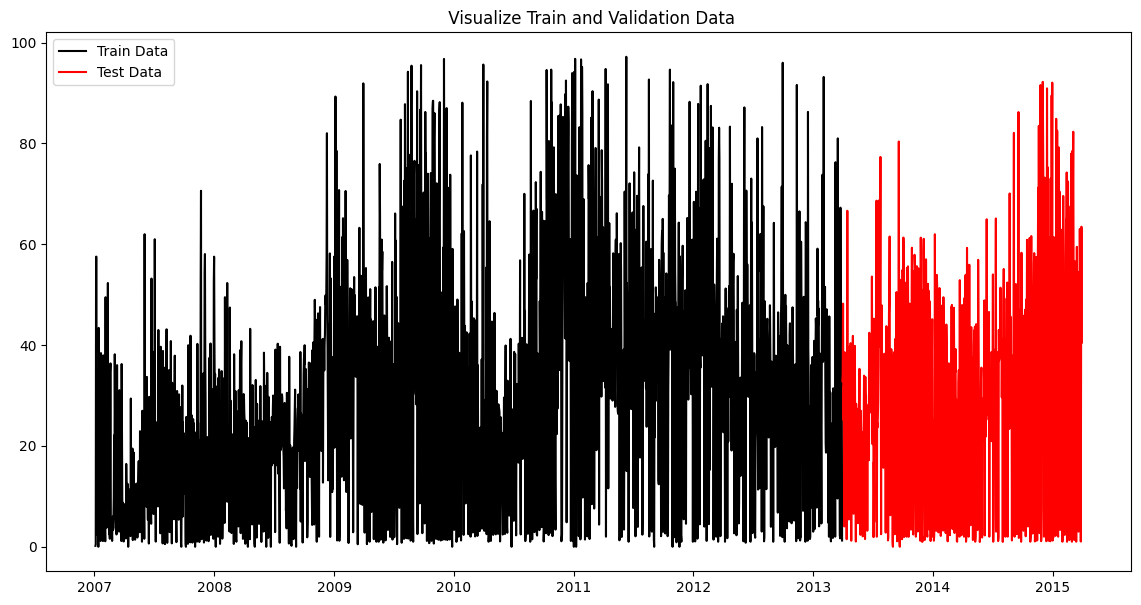

In [ ]:
# Plot the results
plt.figure(figsize=(14, 7))
plt.plot(train_data_df, color='Black', label='Train Data')
plt.plot(val_data_df, color='Red', label='Test Data')
# plt.plot(y_pred_out, color='Blue', label='ARIMA Predictions')
# plt.plot(forecast, label='Forecast')
plt.legend()
plt.title(' Visualize Train and Validation Data')
plt.show()

## ARIMA MODELS

## If the data is not stationary but we want to use a model such as ARIMA (that requires this characteristic), the data has to be transformed.


## The two most common methods to transform series into stationarity ones are:
### Transformation: e.g. log or square root to stabilize non-constant variance
### Differencing: subtracts the current value from the previous

In [ ]:
df_Arima = df[['ave_days']]

In [ ]:
# df_Arima['ave_days']
df_Arima

,ave_days
0,0.179487
1,0.500000
2,57.539966
3,57.539966
4,3.521739
...,...
3004,38.580756
3005,1.040000
3006,42.000000
3007,63.477124


## Adfuller Testing


In [ ]:
# ADF Test
# Function to print out results in customised manner
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput)
# Call the function and run the test

adf_test(dfArima['ave_days'])

Results of Dickey-Fuller Test:
Test Statistic                   -5.159009
p-value                           0.000011
#Lags Used                       27.000000
Number of Observations Used    2981.000000
Critical Value (1%)              -3.432546
Critical Value (5%)              -2.862510
Critical Value (10%)             -2.567286
dtype: float64


## TS Differencing

### This is a simple transformation of the series into a new time series, which we use to remove the series dependence on time and stabilize the mean of the time series, so trend and seasonality are reduced during this transformation.

#### Yt= Yt – Yt-1
#### Yt=Value with time

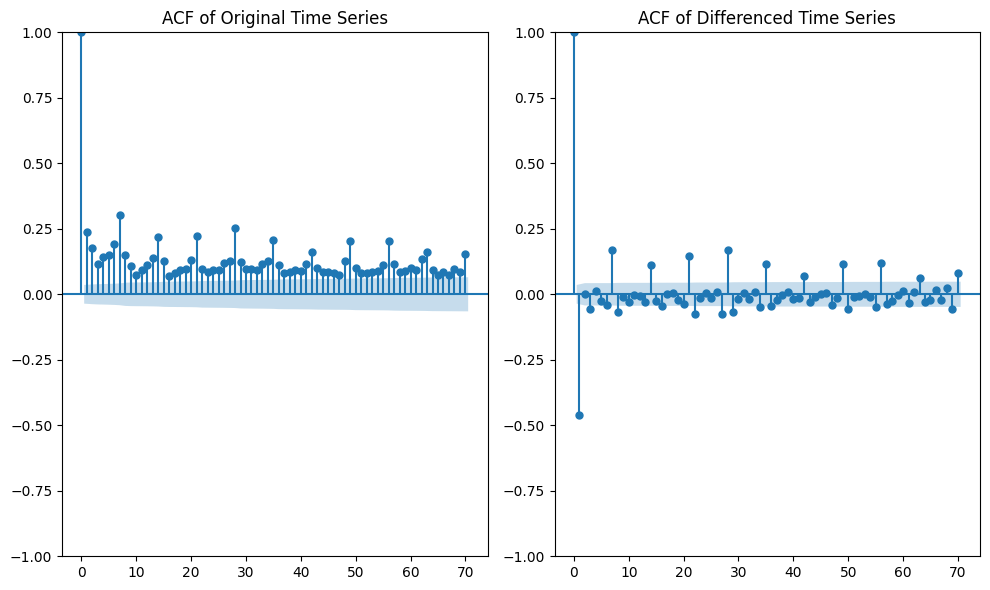

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Assuming 'dfff' is your DataFrame containing the time series data

# Calculate first-order differencee
dfArima_diff = dfArima['ave_days'].diff().dropna()

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

# Plot ACF of original time series
plot_acf(dfArima['ave_days'], ax=axs[0], title='ACF of Original Time Series', lags=70)

# Plot PACF of original time series
# plot_pacf(dfArima['ave_days'], ax=axs[0, 1], title='PACF of Original Time Series', lags=70)

# Plot ACF of differenced time series
plot_acf(dfArima_diff, ax=axs[1], title='ACF of Differenced Time Series', lags=70)

# Plot PACF of differenced time series
# plot_pacf(dfArima_diff, ax=axs[1, 1], title='PACF of Differenced Time Series', lags=70)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()
###diff

### Log transformation: This method involves taking the logarithm of the values of the time series, this removes the exponential growth present in the data.

In [ ]:
log_arima = np.log(df_Arima)
# seasonal differences applied to the data is 28
# to remove the seasonal pattern from the data
seasonal_difference = log_arima.diff(periods = 28)
seasonal_difference

/usr/local/lib/python3.10/dist-packages/pandas/core/internals/blocks.py:329: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


,ave_days
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
3004,-0.703897
3005,-0.907707
3006,3.737670
3007,-0.212555


In [ ]:
seasonal_difference.isna().sum()

ave_days    29
dtype: int64

In [ ]:
seasonal_difference_new = seasonal_difference['ave_days'].dropna()
seasonal_difference_new

28      4.244048
29      2.260621
30     -3.961508
31     -0.150509
32      0.395297
          ...   
3004   -0.703897
3005   -0.907707
3006    3.737670
3007   -0.212555
3008   -0.564202
Name: ave_days, Length: 2980, dtype: float64

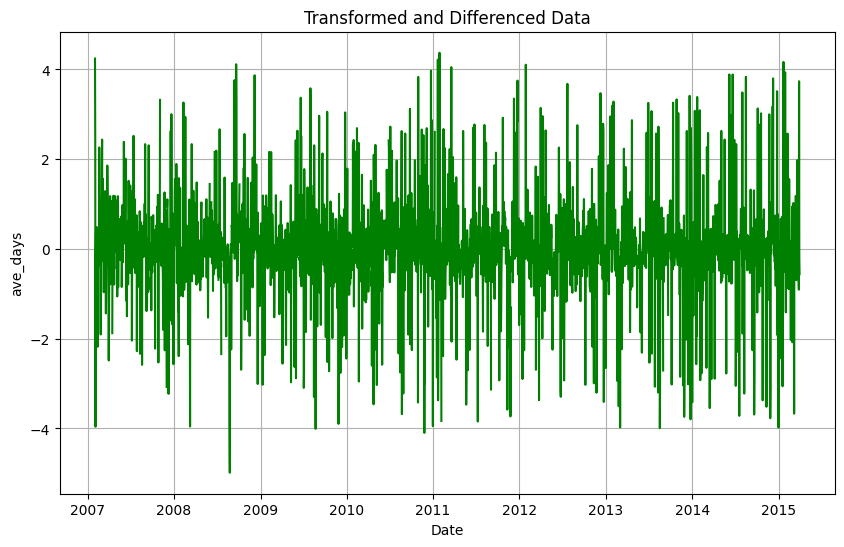

In [ ]:
# Create a line plot of the transformed and differenced data
plt.figure(figsize=(10, 6))
plt.plot(dfArima.index, seasonal_difference, color='green')
plt.title('Transformed and Differenced Data')
plt.xlabel('Date')
plt.ylabel('ave_days')
plt.grid(True)
plt.show()

## Adfuller > Differencing

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Drop missing values from the 'ave_days' column
# seasonal_difference_news_no_missing = seasonal_difference_new['ave_days'].dropna()

# Remove any infinite values (inf) and missing values (nan)
seasonal_difference_cleaned = seasonal_difference_new.replace([np.inf, -np.inf], np.nan).dropna()

# Perform the Augmented Dickey-Fuller test
result = adfuller(seasonal_difference_cleaned, autolag='AIC', regression='n')

# Print the p-value
print('p-value: %f' % result[1])
## The value is less than 0.05

p-value: 0.000000


### ACF & PACF TESTS

### Transformation

In [ ]:
train_data_df

date
2007-01-04     0.179487
2007-01-05     0.500000
2007-01-06    57.539966
2007-01-07    57.539966
2007-01-08     3.521739
                ...    
2013-03-26    25.945813
2013-03-27    31.072948
2013-03-28    44.032738
2013-03-29    33.436364
2013-03-30     1.244898
Name: ave_days, Length: 2278, dtype: float64

In [ ]:
# Apply log transformation
train_data['log_ave_days'] = train_data.ave_days.apply(lambda x: 0 if x == 0 else np.log(x))
val_data['log_ave_days'] = val_data.ave_days.apply(lambda x: 0 if x == 0 else np.log(x))

<ipython-input-39-201739cb1c13>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['log_ave_days'] = train_data.ave_days.apply(lambda x: 0 if x == 0 else np.log(x))
<ipython-input-39-201739cb1c13>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_data['log_ave_days'] = val_data.ave_days.apply(lambda x: 0 if x == 0 else np.log(x))


In [ ]:
train_data

,date,weekday,ave_days,log_ave_days
date,,,,
2007-01-04,2007-01-04,Thursday,0.179487,-1.717651
2007-01-05,2007-01-05,Friday,0.500000,-0.693147
2007-01-06,2007-01-06,Saturday,57.539966,4.052480
2007-01-07,2007-01-07,Sunday,57.539966,4.052480
2007-01-08,2007-01-08,Monday,3.521739,1.258955
...,...,...,...,...
2013-03-26,2013-03-26,Tuesday,25.945813,3.256010
2013-03-27,2013-03-27,Wednesday,31.072948,3.436338
2013-03-28,2013-03-28,Thursday,44.032738,3.784933


In [ ]:
val_data

,date,weekday,ave_days,log_ave_days
date,,,,
2013-03-31,2013-03-31,Sunday,32.854278,3.492082
2013-04-01,2013-04-01,Monday,34.233516,3.533205
2013-04-02,2013-04-02,Tuesday,48.228261,3.875945
2013-04-03,2013-04-03,Wednesday,25.140468,3.224479
2013-04-04,2013-04-04,Thursday,31.764085,3.458336
...,...,...,...,...
2015-03-27,2015-03-27,Friday,38.580756,3.652754
2015-03-28,2015-03-28,Saturday,1.040000,0.039221
2015-03-29,2015-03-29,Sunday,42.000000,3.737670


In [ ]:
logtrain_arima =train_data['log_ave_days']
logtest_arima = val_data['log_ave_days']

## Log Transformed Train vs Test set


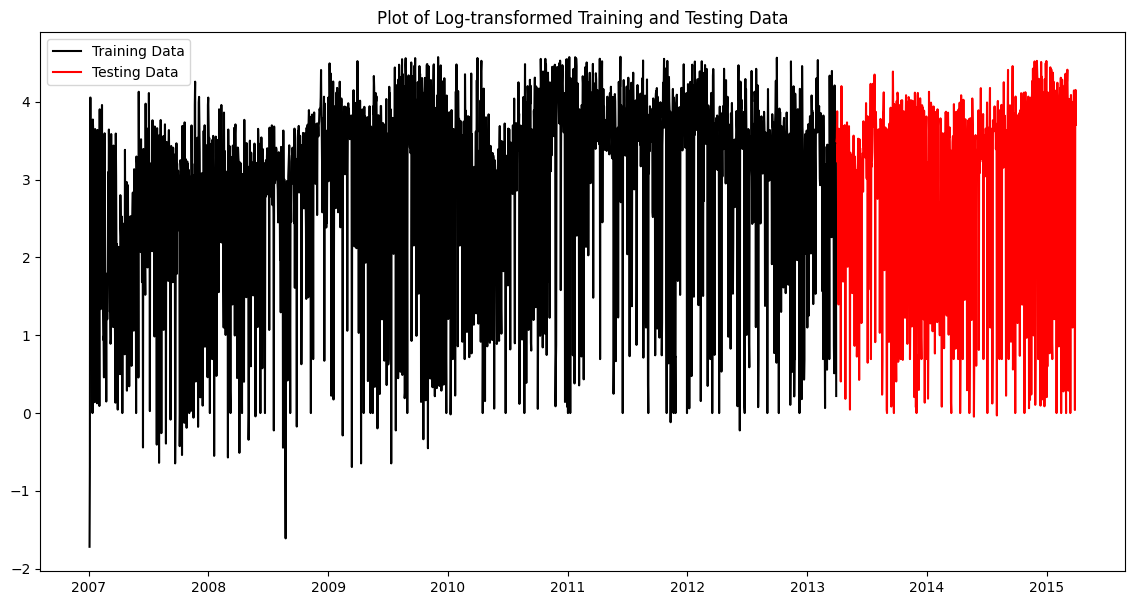

In [ ]:
# Plot the results
plt.figure(figsize=(14, 7))

plt.plot(logtrain_arima, color='Black', label='Training Data')
plt.plot(logtest_arima,color='Red', label='Testing Data')
# plt.plot(logtrain_arima, color='Black', label='Train Data')
# plt.plot(logtest_arima, color='Red', label='Test Data')
# plt.plot(y_pred_out, color='Blue', label='ARIMA Predictions')
# plt.fill_between(y_pred_df.index, y_pred_df.iloc[:, 0], y_pred_df.iloc[:, 1], color='k', alpha=0.1) # confidence interval
plt.legend()
plt.title('Plot of Log-transformed Training and Testing Data')
plt.show()

In [ ]:
logtrain_arima

date
2007-01-04   -1.717651
2007-01-05   -0.693147
2007-01-06    4.052480
2007-01-07    4.052480
2007-01-08    1.258955
                ...   
2013-03-26    3.256010
2013-03-27    3.436338
2013-03-28    3.784933
2013-03-29    3.509644
2013-03-30    0.219054
Name: log_ave_days, Length: 2278, dtype: float64

In [ ]:
print(logtest_arima.shape[0] - 1)

730


# Arima Models

### Parameters (0, 1, 0, 24)

C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


MAE: 45.42
AIC: 9683.54


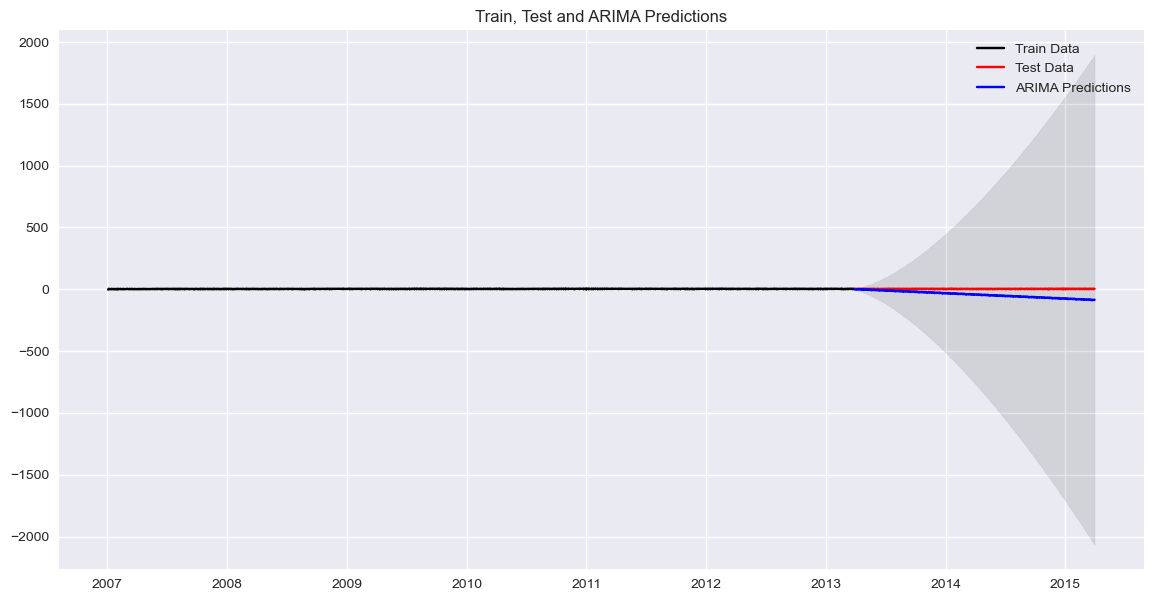

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         4.3029      0.131     32.896      0.000       4.047       4.559


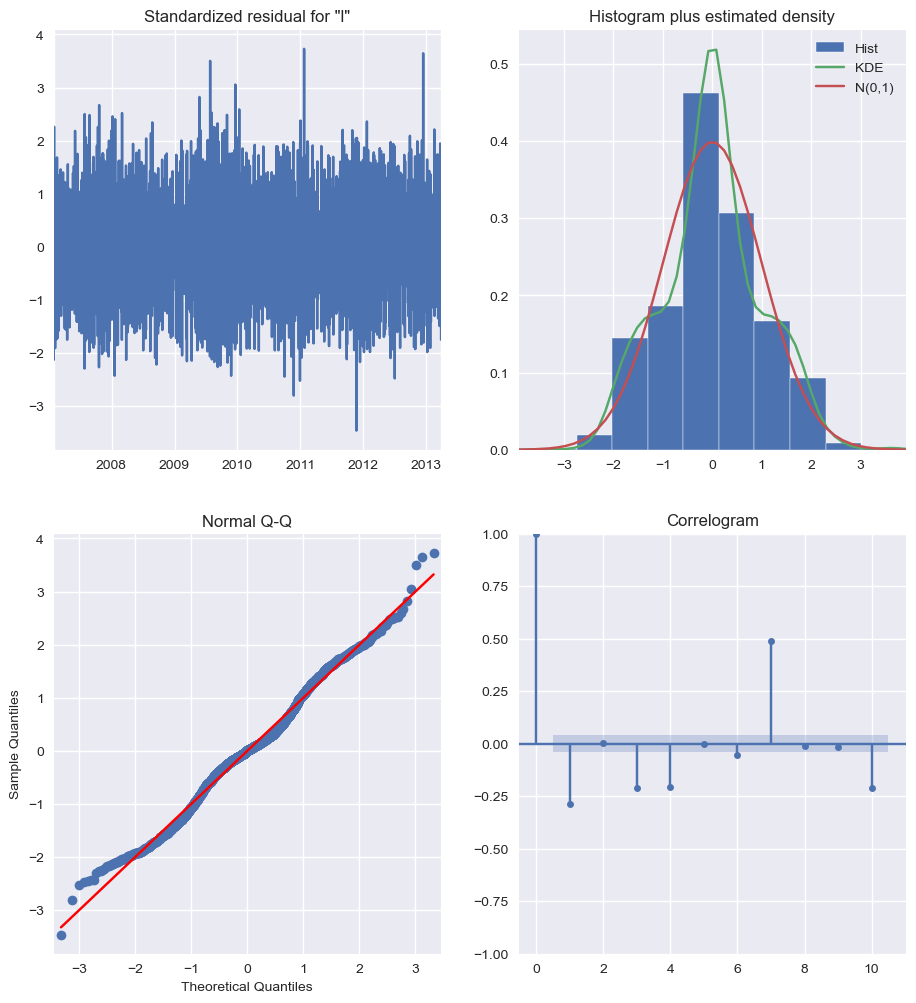

In [ ]:
ARIMAmodel = ARIMA(logtrain_arima, order = (0, 1, 0),
                                   seasonal_order=(0, 1, 0, 24))
ARIMAmodel = ARIMAmodel.fit()
# print(ARIMAmodel.summary())

y_pred = ARIMAmodel.get_forecast(len(logtest_arima.index))
y_pred_df = y_pred.conf_int(alpha = 0.05)
y_pred_df["Predictions"] = ARIMAmodel.predict(start = y_pred_df.index[0], end = y_pred_df.index[-1])
y_pred_df.index = logtest_arima.index
y_pred_out = y_pred_df["Predictions"]
# plt.plot(y_pred_out, color='Blue', label = 'ARIMA Predictions')
# plt.legend()

# Calculate MAE
mae = np.mean(np.abs(logtest_arima - y_pred_out))
print(f'MAE: {mae:.2f}')

# Retrieve AIC
aic = ARIMAmodel.aic
print(f'AIC: {aic:.2f}')

# Plot the results
plt.figure(figsize=(14, 7))
plt.plot(logtrain_arima, color='Black', label='Train Data')
plt.plot(logtest_arima, color='Red', label='Test Data')
plt.plot(y_pred_out, color='Blue', label='ARIMA Predictions')
plt.fill_between(y_pred_df.index, y_pred_df.iloc[:, 0], y_pred_df.iloc[:, 1], color='k', alpha=0.1) # confidence interval
plt.legend()
plt.title('Train, Test and ARIMA Predictions')
plt.show()

# print(ARIMAmodel.summary())
# ARIMAmodel.plot_diagnostics(figsize=(15, 12))
print(ARIMAmodel.summary().tables[1])
residuals_default = ARIMAmodel.plot_diagnostics(figsize=(11, 12))
plt.show()


### Parameters (0, 1, 0, 7)

C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


MAE: 34.48
AIC: 8184.25


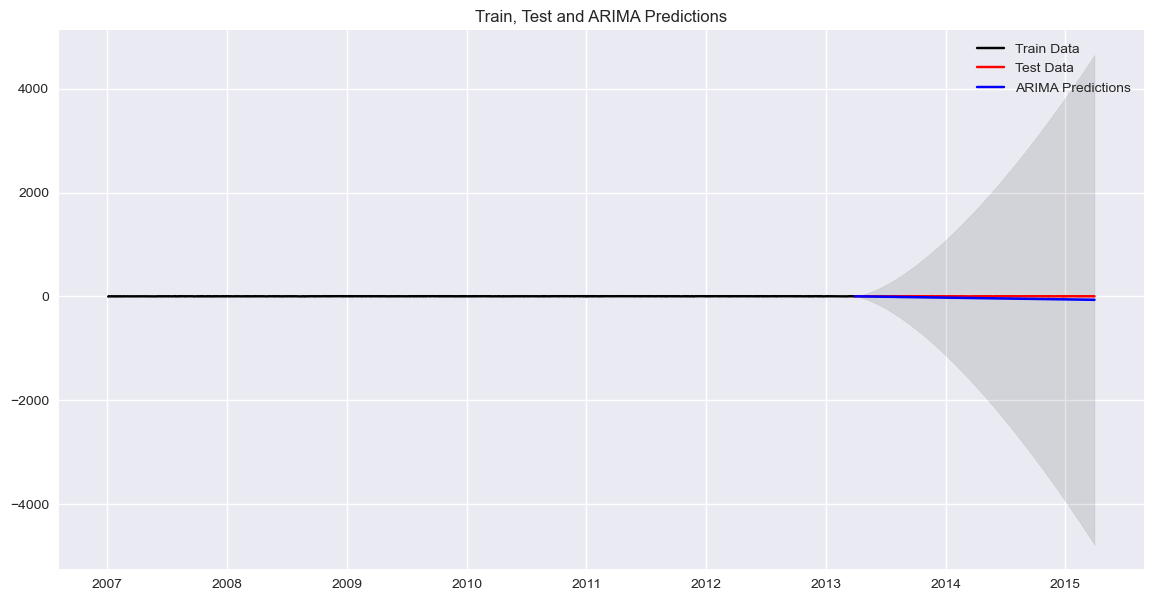

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         2.1525      0.041     52.007      0.000       2.071       2.234


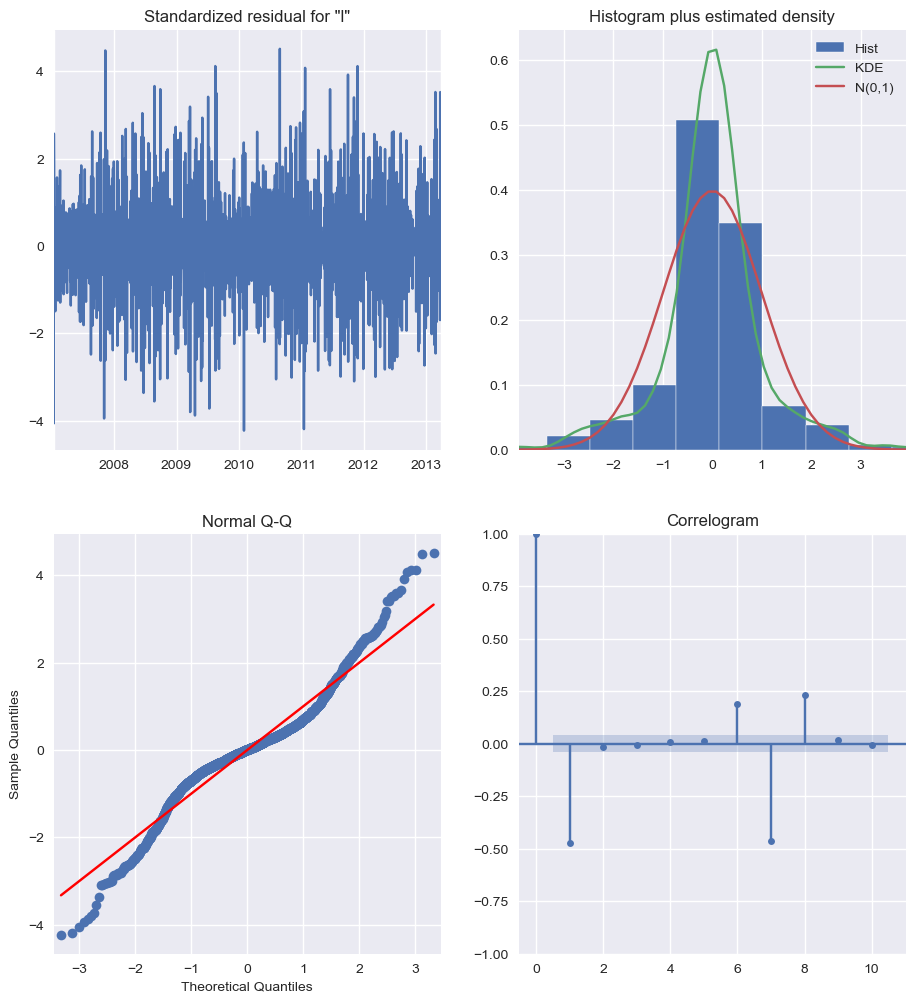

In [ ]:
ARIMAmodel = ARIMA(logtrain_arima, order = (0, 1, 0),
                                   seasonal_order=(0, 1, 0, 7))
ARIMAmodel = ARIMAmodel.fit()
# print(ARIMAmodel.summary())

y_pred = ARIMAmodel.get_forecast(len(logtest_arima.index))
y_pred_df = y_pred.conf_int(alpha = 0.05)
y_pred_df["Predictions"] = ARIMAmodel.predict(start = y_pred_df.index[0], end = y_pred_df.index[-1])
y_pred_df.index = logtest_arima.index
y_pred_out = y_pred_df["Predictions"]
# plt.plot(y_pred_out, color='Blue', label = 'ARIMA Predictions')
# plt.legend()

# Calculate MAE
mae = np.mean(np.abs(logtest_arima - y_pred_out))
print(f'MAE: {mae:.2f}')

# Retrieve AIC
aic = ARIMAmodel.aic
print(f'AIC: {aic:.2f}')

# Plot the results
plt.figure(figsize=(14, 7))
plt.plot(logtrain_arima, color='Black', label='Train Data')
plt.plot(logtest_arima, color='Red', label='Test Data')
plt.plot(y_pred_out, color='Blue', label='ARIMA Predictions')
plt.fill_between(y_pred_df.index, y_pred_df.iloc[:, 0], y_pred_df.iloc[:, 1], color='k', alpha=0.1) # confidence interval
plt.legend()
plt.title('Train, Test and ARIMA Predictions')
plt.show()

# print(ARIMAmodel.summary())
# ARIMAmodel.plot_diagnostics(figsize=(15, 12))
# plt.show()

print(ARIMAmodel.summary().tables[1])
residuals_default = ARIMAmodel.plot_diagnostics(figsize=(11, 12))
plt.show()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


MAE: 2.41
AIC: 8180.11


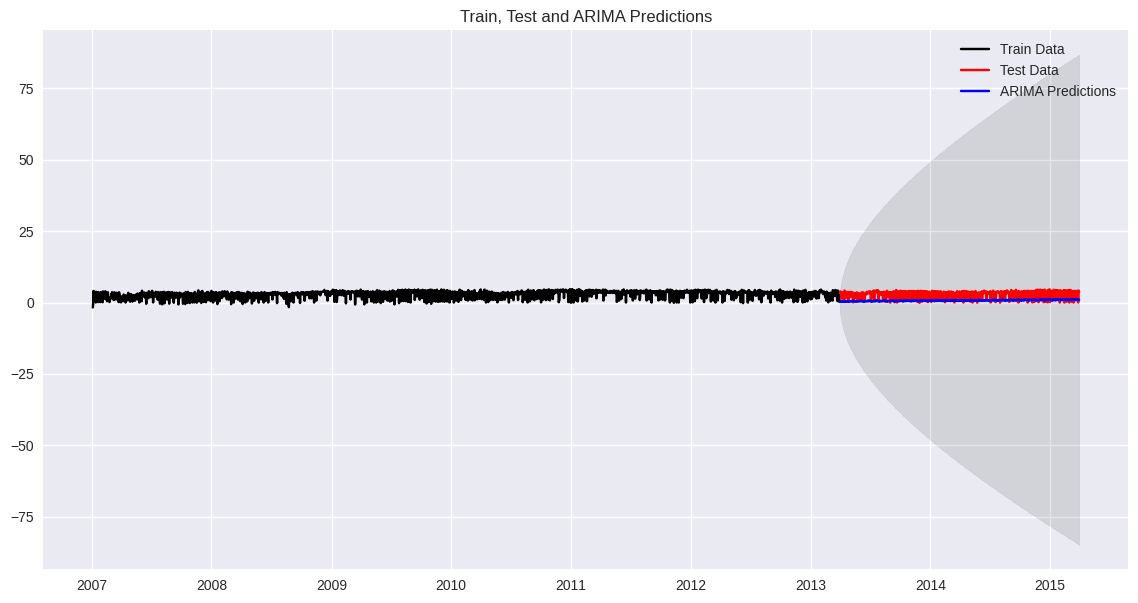

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L24      -0.0295      0.036     -0.820      0.412      -0.100       0.041
ma.S.L24      -0.9995      0.399     -2.507      0.012      -1.781      -0.218
sigma2         2.0993      0.827      2.540      0.011       0.479       3.719


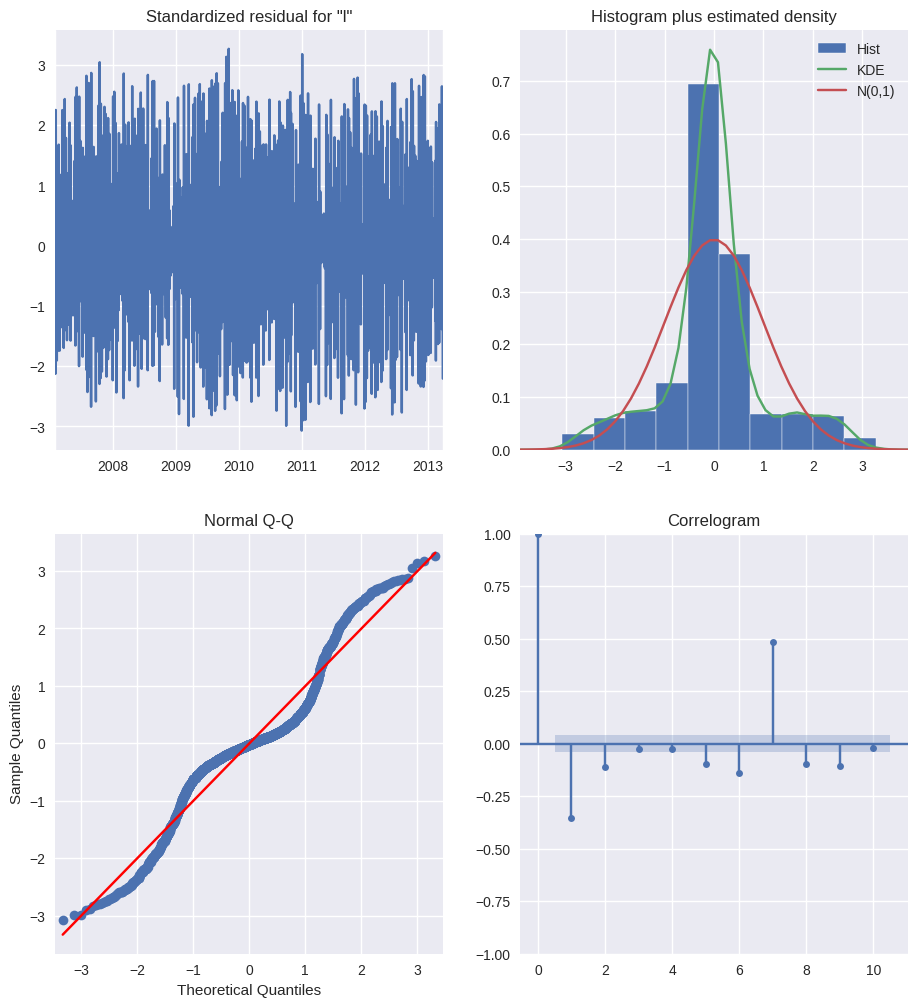

In [ ]:
ARIMAmodel = ARIMA(logtrain_arima, order = (0, 1, 0),
                                   seasonal_order=(1, 1, 1, 24))
ARIMAmodel = ARIMAmodel.fit()
# print(ARIMAmodel.summary())

y_pred = ARIMAmodel.get_forecast(len(logtest_arima.index))
y_pred_df = y_pred.conf_int(alpha = 0.05)
y_pred_df["Predictions"] = ARIMAmodel.predict(start = y_pred_df.index[0], end = y_pred_df.index[-1])
y_pred_df.index = logtest_arima.index
y_pred_out = y_pred_df["Predictions"]
# plt.plot(y_pred_out, color='Blue', label = 'ARIMA Predictions')
# plt.legend()

# Calculate MAE
mae = np.mean(np.abs(logtest_arima - y_pred_out))
print(f'MAE: {mae:.2f}')

# Retrieve AIC
aic = ARIMAmodel.aic
print(f'AIC: {aic:.2f}')

# Plot the results
plt.figure(figsize=(14, 7))
plt.plot(logtrain_arima, color='Black', label='Train Data')
plt.plot(logtest_arima, color='Red', label='Test Data')
plt.plot(y_pred_out, color='Blue', label='ARIMA Predictions')
plt.fill_between(y_pred_df.index, y_pred_df.iloc[:, 0], y_pred_df.iloc[:, 1], color='k', alpha=0.1) # confidence interval
plt.legend()
plt.title('Train, Test and ARIMA Predictions')
plt.show()

# print(ARIMAmodel.summary())
# ARIMAmodel.plot_diagnostics(figsize=(15, 12))
# plt.show()

print(ARIMAmodel.summary().tables[1])
residuals_default = ARIMAmodel.plot_diagnostics(figsize=(11, 12))
plt.show()

### Hyperparameters

In [ ]:
### Hyperparameters

In [ ]:
import time
import datetime
from tqdm.notebook import tqdm
import warnings
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

# Replace this with your actual time series data
# logtrain_arima = pd.Series([...])  # Example placeholder, replace with actual data
logtrain_arima = logtrain_arima.copy()

# Initialize variables
best_logL = -999999
start = time.time()

# Suppress warnings
warnings.filterwarnings("ignore")

# Define parameter ranges for ARIMA
p_range = range(7)
d_range = [1]  # Usually d is fixed at 1 for differencing
q_range = range(7)
seasonal_order = (1, 1, 1, 7)

# Track results
results_params = []
results_aic = []

# Grid search for best ARIMA parameters
for i in tqdm(p_range, desc='Outer loop'):
    for j in tqdm(q_range, desc='Inner loop', leave=False):
        try:
            # Fit ARIMA model
            mod3 = ARIMA(logtrain_arima, order=(i, 1, j), seasonal_order=seasonal_order)
            mod3 = mod3.fit()
            logL = mod3.llf

            # Update best log-likelihood
            if logL >= best_logL:
                best_logL = logL
                best_params = (i, j)

            # Print current status
            print('AR {} -- MA {},  Log-Likelihood: {}, Best Log-Likelihood: {}, (ARMA {})'.format(
                i, j, round(logL, 2), round(best_logL, 2), best_params))

        except Exception as e:
            print(f"Exception for AR {i} MA {j}: {e}")
            continue

# Define pdq and seasonal_pdq ranges
pdq = [(p, d, q) for p in range(7) for d in [1] for q in range(7)]  # Adjust as needed
seasonal_pdq = [(1, 1, 1, 24)]  # Modify as needed

# Additional model fitting with SARIMAX
for param in tqdm(pdq, desc='SARIMA outer loop'):
    for param_seasonal in tqdm(seasonal_pdq, desc='SARIMA inner loop', leave=False):
        try:
            # Fit SARIMAX model
            mod = sm.tsa.statespace.SARIMAX(logtrain_arima,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)

            results = mod.fit()

            # Print and store results
            print('ARIMA{}x{}24 - AIC:{}'.format(param, param_seasonal, results.aic))
            results_params.append(str(param) + 'x' + str(param_seasonal))
            results_aic.append(results.aic)

        except Exception as e:
            print(f"Exception for ARIMA{param}x{param_seasonal}: {e}")
            continue

# Print best results (if needed)
best_aic_idx = results_aic.index(min(results_aic))
print(f'Best SARIMAX configuration: {results_params[best_aic_idx]} with AIC: {min(results_aic)}')

# End time
end = time.time()
print(f'Total time: {datetime.timedelta(seconds=end - start)}')

# Best SARIMAX configuration: (6, 1, 6)x(1, 1, 1, 24) with AIC: 6001.159872969234
# Total time: 0:37:13.982341


Outer loop:   0%|          | 0/7 [00:00<?, ?it/s]

Inner loop:   0%|          | 0/7 [00:00<?, ?it/s]

AR 0 -- MA 0,  Log-Likelihood: -3517.11, Best Log-Likelihood: -3517.11, (ARMA (0, 0))
AR 0 -- MA 1,  Log-Likelihood: -2835.89, Best Log-Likelihood: -2835.89, (ARMA (0, 1))
AR 0 -- MA 2,  Log-Likelihood: -2831.52, Best Log-Likelihood: -2831.52, (ARMA (0, 2))
AR 0 -- MA 3,  Log-Likelihood: -2830.39, Best Log-Likelihood: -2830.39, (ARMA (0, 3))
AR 0 -- MA 4,  Log-Likelihood: -2830.33, Best Log-Likelihood: -2830.33, (ARMA (0, 4))
AR 0 -- MA 5,  Log-Likelihood: -2830.31, Best Log-Likelihood: -2830.31, (ARMA (0, 5))
AR 0 -- MA 6,  Log-Likelihood: -2830.13, Best Log-Likelihood: -2830.13, (ARMA (0, 6))


Inner loop:   0%|          | 0/7 [00:00<?, ?it/s]

AR 1 -- MA 0,  Log-Likelihood: -3219.08, Best Log-Likelihood: -2830.13, (ARMA (0, 6))
AR 1 -- MA 1,  Log-Likelihood: -2831.24, Best Log-Likelihood: -2830.13, (ARMA (0, 6))
AR 1 -- MA 2,  Log-Likelihood: -2830.39, Best Log-Likelihood: -2830.13, (ARMA (0, 6))
AR 1 -- MA 3,  Log-Likelihood: -2830.83, Best Log-Likelihood: -2830.13, (ARMA (0, 6))
AR 1 -- MA 4,  Log-Likelihood: -2830.13, Best Log-Likelihood: -2830.13, (ARMA (1, 4))
AR 1 -- MA 5,  Log-Likelihood: -2830.11, Best Log-Likelihood: -2830.11, (ARMA (1, 5))
AR 1 -- MA 6,  Log-Likelihood: -2829.55, Best Log-Likelihood: -2829.55, (ARMA (1, 6))


...

ARIMA(6, 1, 4)x(1, 1, 1, 24)24 - AIC:6113.198217490693


SARIMA inner loop:   0%|          | 0/1 [00:00<?, ?it/s]

ARIMA(6, 1, 5)x(1, 1, 1, 24)24 - AIC:6009.362018717497


SARIMA inner loop:   0%|          | 0/1 [00:00<?, ?it/s]

ARIMA(6, 1, 6)x(1, 1, 1, 24)24 - AIC:6001.159872969234
Best SARIMAX configuration: (6, 1, 6)x(1, 1, 1, 24) with AIC: 6001.159872969234
Total time: 0:37:13.982341


Parameters : order = (6, 1, 6), seasonal_order=(0, 1, 0, 24))

C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



                                     SARIMAX Results                                     
Dep. Variable:                      log_ave_days   No. Observations:                 2278
Model:             ARIMA(6, 1, 6)x(0, 1, [], 24)   Log Likelihood               -3686.918
Date:                           Mon, 20 May 2024   AIC                           7399.836
Time:                                   15:00:44   BIC                           7474.197
Sample:                               01-04-2007   HQIC                          7426.976
                                    - 03-30-2013                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9417      0.082    -11.473      0.000      -1.103      -0.781
ar.L2         -0.3123      0.061     -5.161

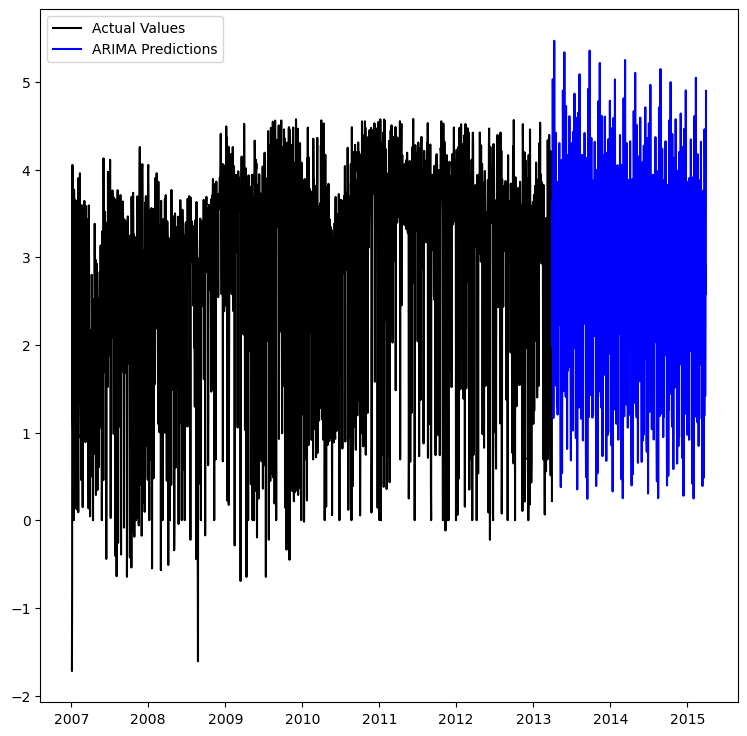

In [ ]:
ARIMAmodel = ARIMA(logtrain_arima, order = (6, 1, 6),
                                   seasonal_order=(0, 1, 0, 24))
ARIMAmodel = ARIMAmodel.fit()
print(ARIMAmodel.summary())

y_pred = ARIMAmodel.get_forecast(len(logtest_arima.index))
y_pred_df = y_pred.conf_int(alpha = 0.05)
y_pred_df["Predictions"] = ARIMAmodel.predict(start = y_pred_df.index[0], end = y_pred_df.index[-1])
y_pred_df.index = logtest_arima.index
y_pred_out = y_pred_df["Predictions"]
plt.plot(logtrain_arima, color='black', label = 'Actual Values')
plt.plot(y_pred_out, color='Blue', label = 'ARIMA Predictions')
plt.legend()

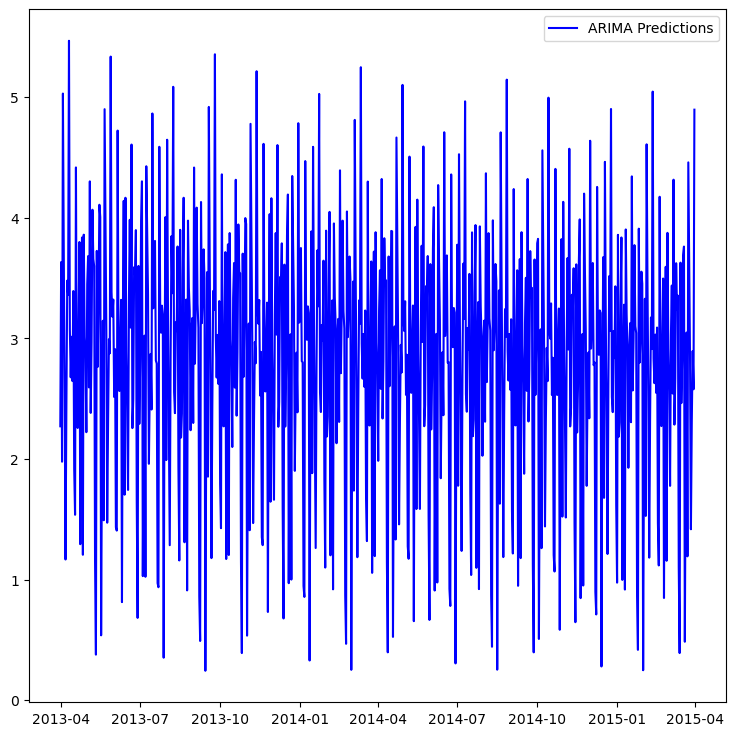

In [ ]:

# y_pred = ARIMAmodel.get_forecast(len(logtest_arima.index))
# y_pred_df = y_pred.conf_int(alpha = 0.05)
# y_pred_df["Predictions"] = ARIMAmodel.predict(start = y_pred_df.index[0], end = y_pred_df.index[-1])
# y_pred_df.index = logtest_arima.index
# y_pred_out = y_pred_df["Predictions"]
# plt.plot(logtrain_arima, color='Black', label = 'Actual Values')
plt.plot(y_pred_out, color='Blue', label = 'ARIMA Predictions')
plt.legend()

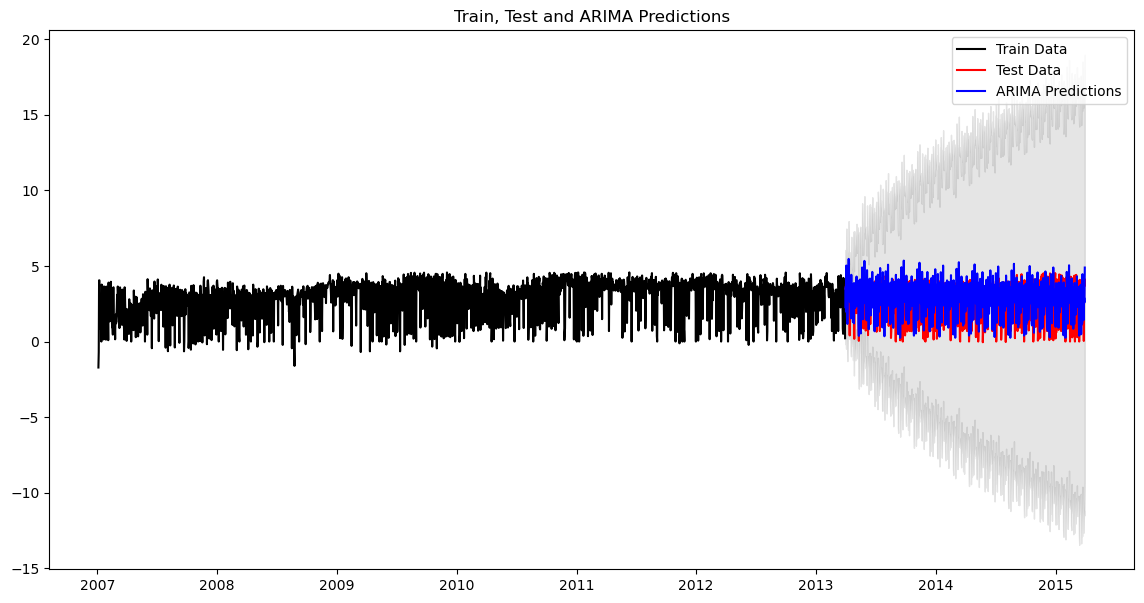

In [ ]:
# Plot the results
plt.figure(figsize=(14, 7))
plt.plot(logtrain_arima, color='Black', label='Train Data')
plt.plot(logtest_arima, color='Red', label='Test Data')
plt.plot(y_pred_out, color='Blue', label='ARIMA Predictions')
plt.fill_between(y_pred_df.index, y_pred_df.iloc[:, 0], y_pred_df.iloc[:, 1], color='k', alpha=0.1) # confidence interval
plt.legend()
plt.title('Train, Test and ARIMA Predictions')
plt.show()

### order = (6, 1, 6), seasonal_order=(0, 1, 0, 24))

C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



MAE: 1.17
AIC: 7399.84


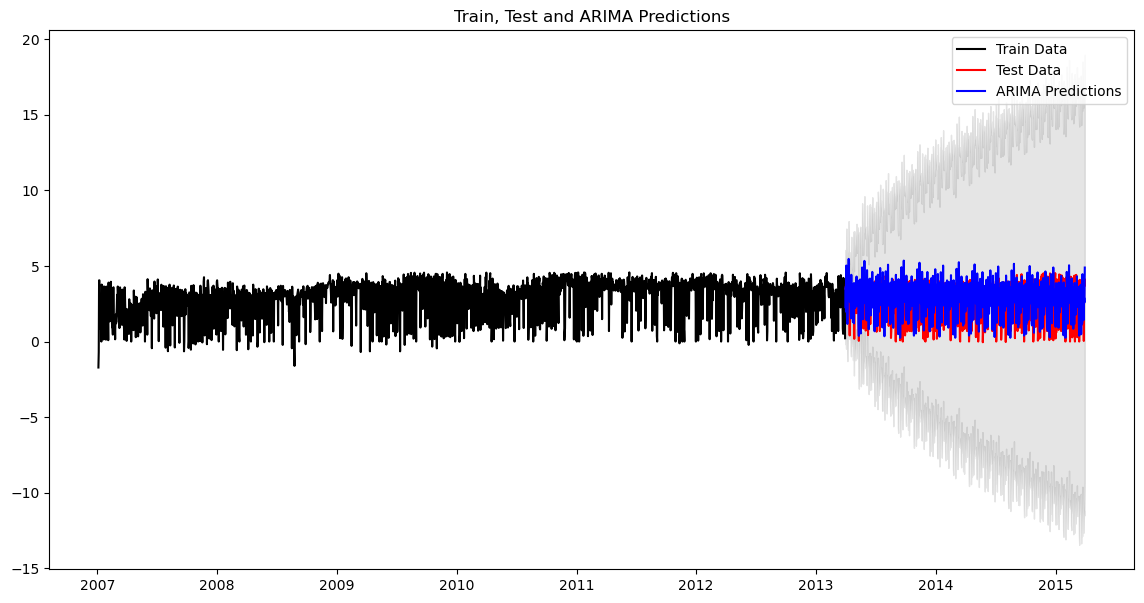

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Assuming logtrain_arima and logtest_arima are your preprocessed time series data

# Fit the ARIMA model
ARIMAmodel = ARIMA(logtrain_arima, order=(6, 1, 6),
                                   seasonal_order=(0, 1, 0, 24))
ARIMAmodel = ARIMAmodel.fit()
# print(ARIMAmodel.summary())

# Generate predictions
y_pred = ARIMAmodel.get_forecast(len(logtest_arima.index))
y_pred_df = y_pred.conf_int(alpha=0.05)
y_pred_df["Predictions"] = ARIMAmodel.predict(start=y_pred_df.index[0], end=y_pred_df.index[-1])
y_pred_df.index = logtest_arima.index
y_pred_out = y_pred_df["Predictions"]

# # Calculate MAPE
# mape = np.mean(np.abs((logtest_arima - y_pred_out) / logtest_arima)) * 100
# print(f'MAPE: {mape:.2f}%')

# Calculate MAE
mae = np.mean(np.abs(logtest_arima - y_pred_out))
print(f'MAE: {mae:.2f}')

# Retrieve AIC
aic = ARIMAmodel.aic
print(f'AIC: {aic:.2f}')

# Plot the results
plt.figure(figsize=(14, 7))
plt.plot(logtrain_arima, color='Black', label='Train Data')
plt.plot(logtest_arima, color='Red', label='Test Data')
plt.plot(y_pred_out, color='Blue', label='ARIMA Predictions')
plt.fill_between(y_pred_df.index, y_pred_df.iloc[:, 0], y_pred_df.iloc[:, 1], color='k', alpha=0.1) # confidence interval
plt.legend()
plt.title('Train, Test and ARIMA Predictions')
plt.show()


                                     SARIMAX Results                                     
Dep. Variable:                      log_ave_days   No. Observations:                 2278
Model:             ARIMA(6, 1, 6)x(0, 1, [], 24)   Log Likelihood               -3686.918
Date:                           Mon, 20 May 2024   AIC                           7399.836
Time:                                   14:54:05   BIC                           7474.197
Sample:                               01-04-2007   HQIC                          7426.976
                                    - 03-30-2013                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9417      0.082    -11.473      0.000      -1.103      -0.781
ar.L2         -0.3123      0.061     -5.161

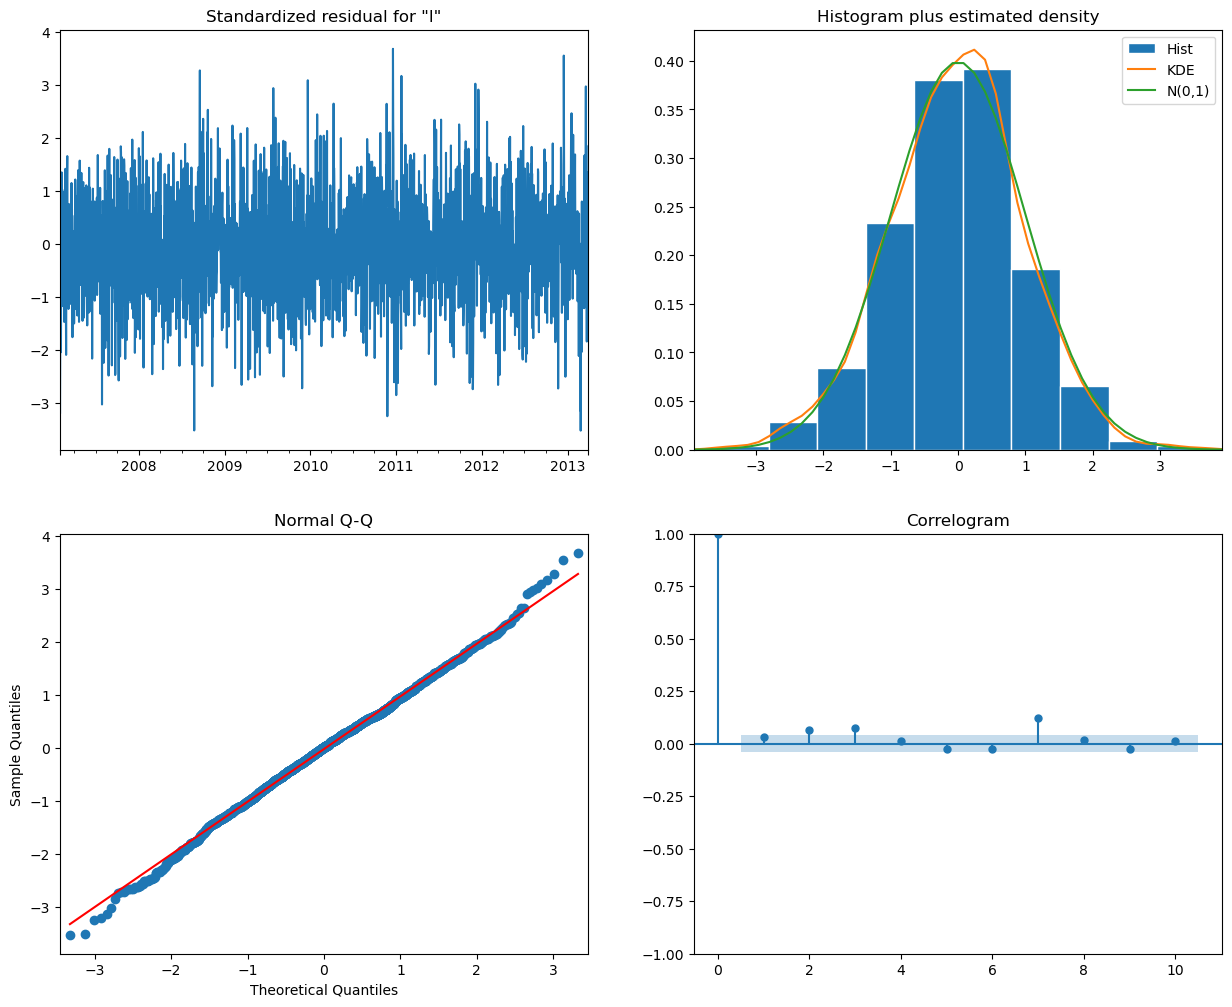

In [ ]:
print(ARIMAmodel.summary())
ARIMAmodel.plot_diagnostics(figsize=(15, 12))
plt.show()

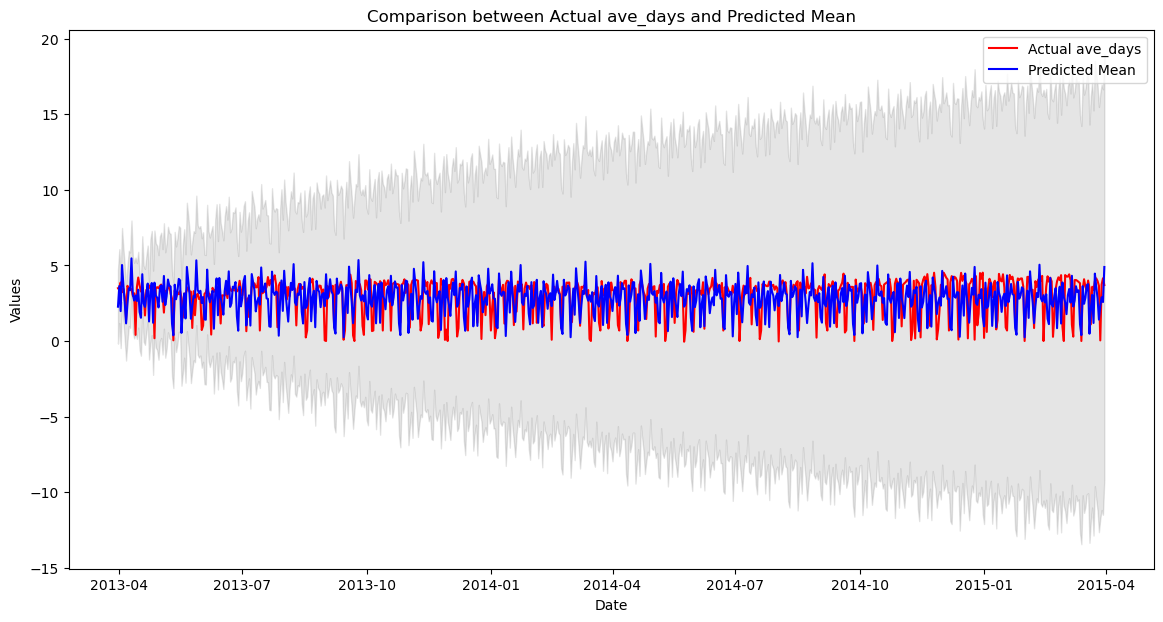

In [ ]:
# Plot the comparison between actual values and predictions
plt.figure(figsize=(14, 7))
plt.plot(logtest_arima.index, logtest_arima, color='Red', label='Actual ave_days')
plt.plot(logtest_arima.index, y_pred_out, color='Blue', label='Predicted Mean')
plt.fill_between(y_pred_df.index, y_pred_df.iloc[:, 0], y_pred_df.iloc[:, 1], color='k', alpha=0.1) # confidence interval
plt.legend()
plt.title('Comparison between Actual ave_days and Predicted Mean')
plt.xlabel('Date')
plt.ylabel('Values')
plt.show()

In [ ]:
logtrain_arima

date
2007-01-04   -1.717651
2007-01-05   -0.693147
2007-01-06    4.052480
2007-01-07    4.052480
2007-01-08    1.258955
                ...   
2013-03-26    3.256010
2013-03-27    3.436338
2013-03-28    3.784933
2013-03-29    3.509644
2013-03-30    0.219054
Name: log_ave_days, Length: 2278, dtype: float64

## Forecasts from 2015-04-01 through 2015-11-07

In [ ]:
merged_log_train_test = pd.concat([logtrain_arima, logtest_arima])
merged_log_train_test = merged_log_train_test.to_frame()
merged_log_train_test

,log_ave_days
date,
2007-01-04,-1.717651
2007-01-05,-0.693147
2007-01-06,4.052480
2007-01-07,4.052480
2007-01-08,1.258955
...,...
2015-03-27,3.652754
2015-03-28,0.039221
2015-03-29,3.737670


In [ ]:

# Generate date range from 2015-04-01 to 2015-11-07
new_dates = pd.date_range(start='2015-04-01 00:00:00', end='2015-11-07 00:00:00', freq='D')

# Create a DataFrame with the new dates
new_df = pd.DataFrame({'date': new_dates})

# Merge new DataFrame with existing DataFrame df
extended_df = pd.merge(merged_log_train_test, new_df, on='date', how='outer')

# Sort the DataFrame by date
extended_df.sort_values(by='date', inplace=True)

# Forward fill missing values for columns other than 'date'
# extended_df.fillna(method='ffill', inplace=True)

# Display the extended DataFrame
# print(extended_df)


In [ ]:
extended_data = extended_df.copy()
extended_data.set_index('date', inplace=True)
extended_data

,log_ave_days
date,
2007-01-04,-1.717651
2007-01-05,-0.693147
2007-01-06,4.052480
2007-01-07,4.052480
2007-01-08,1.258955
...,...
2015-11-03,NaN
2015-11-04,NaN
2015-11-05,NaN


In [ ]:
from statsmodels.tsa.deterministic import DeterministicProcess

# Instantiate the DeterministicProcess class with daily periodicity and Fourier terms
deterministic_process = DeterministicProcess(c.index, period=24, fourier=3)

# Perform some operation on the in-sample data
in_sample_data_operation = deterministic_process.in_sample()
# Further analysis or processing on the in-sample data as needed


In [ ]:
df_sdo = in_sample_data_operation.copy()
# Filter the data for training and validation
exog_train = df_sdo[df_sdo.index < '2015-04-01']
exog_test = df_sdo[df_sdo.index >= '2015-04-01']

In [ ]:

mod01 = ARIMA(merged_log_train_test,
            order=(6, 1, 6),
            seasonal_order=(0, 1, 0, 28),
            exog=exog_train)

mod01 = mod01.fit()


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
forecast_steps = len(exog_test)
forecast = mod01.forecast(steps= forecast_steps, exog=exog_test)
forecast


2015-04-01    3.867985
2015-04-02    4.135728
2015-04-03    4.157197
2015-04-04    0.929238
2015-04-05    0.921234
                ...   
2015-11-03    4.009350
2015-11-04    4.459933
2015-11-05    3.982842
2015-11-06    3.682903
2015-11-07    0.170600
Freq: D, Name: predicted_mean, Length: 221, dtype: float64

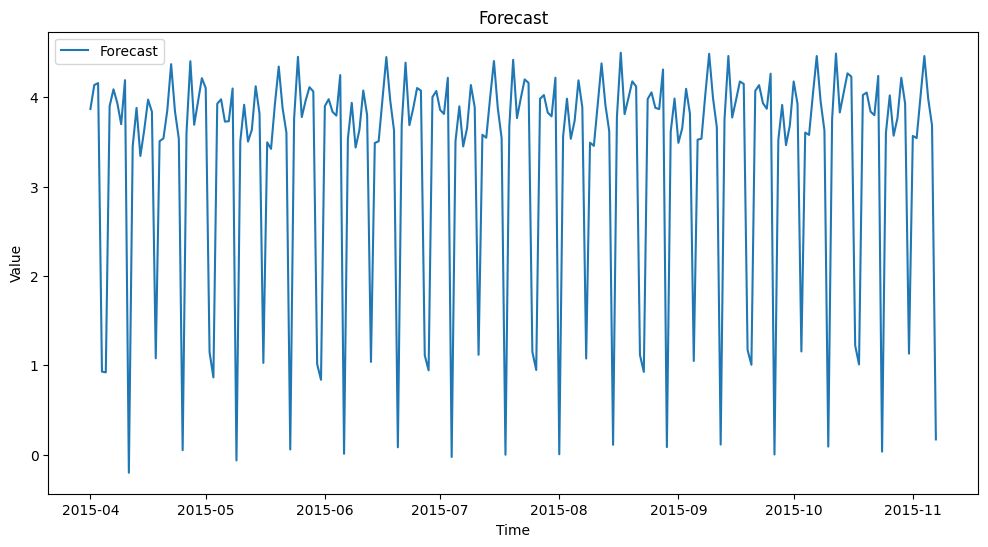

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(forecast, label='Forecast')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Forecast')
plt.legend()
plt.show()

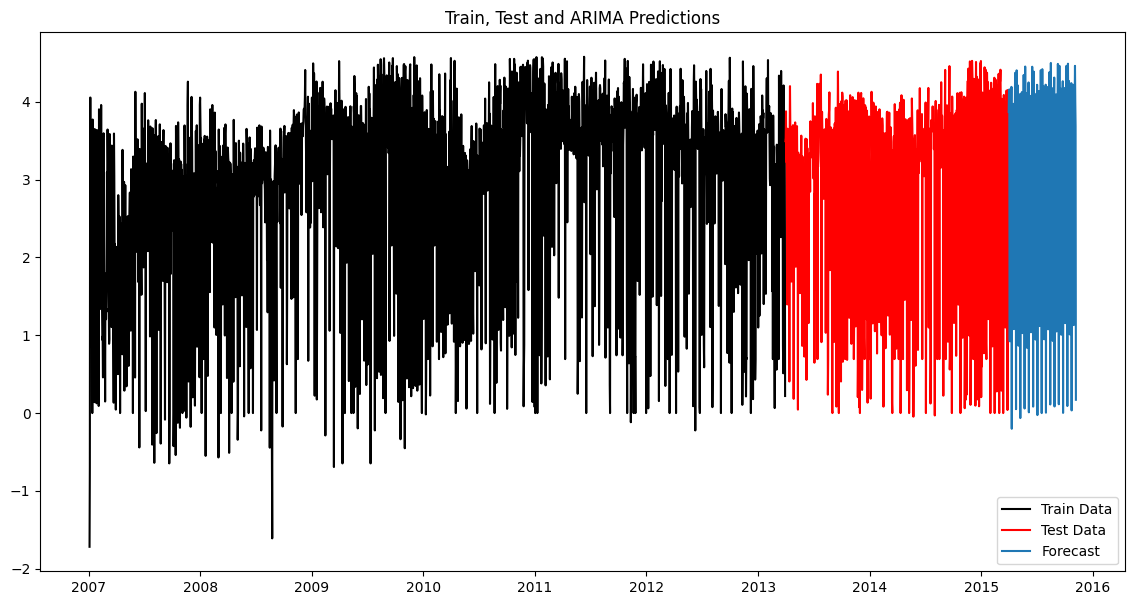

In [ ]:
# Plot the results
plt.figure(figsize=(14, 7))
plt.plot(logtrain_arima, color='Black', label='Train Data')
plt.plot(logtest_arima, color='Red', label='Test Data')
# plt.plot(y_pred_out, color='Blue', label='ARIMA Predictions')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.title('Train, Test and ARIMA Predictions')
plt.show()

In [ ]:
# Saving th results in the dataframe

columns = ["Date", "ARIMA", "UCM", "ML"]
Pred_results = pd.DataFrame(columns = columns)
Pred_results['Date'] = dates_forecasts

Pred_results['Date'] = pd.to_datetime(Pred_results['Date']).dt.date

# saving the results of the arima model
Pred_results['ARIMA'] = forecast.values
Pred_results

,Date,ARIMA,UCM,ML
0,2015-04-01,3.867985,NaN,NaN
1,2015-04-02,4.135728,NaN,NaN
2,2015-04-03,4.157197,NaN,NaN
3,2015-04-04,0.929238,NaN,NaN
4,2015-04-05,0.921234,NaN,NaN
...,...,...,...,...
216,2015-11-03,4.009350,NaN,NaN
217,2015-11-04,4.459933,NaN,NaN
218,2015-11-05,3.982842,NaN,NaN
219,2015-11-06,3.682903,NaN,NaN


In [ ]:
Pred_results.to_csv('Pred_resultsA.csv')
# dfPred_resultsA = pd.read_csv('Pred_resultsA.csv')

# UCM models

## Level Evaluation

In [ ]:
levels = ['ntrend','llevel','rwalk','lldtrend','rwdrift','lltrend','strend','rtrend']

for l in levels:
    model = sm.tsa.UnobservedComponents(logtrain_arima, level=l, cycle=True, seasonal=24, stochastic_seasonal=True)
    model = model.fit()
    prediction = model.forecast(steps=len(logtest_arima))
    predictions = pd.Series(prediction, index=logtest_arima.index)
    residuals = logtest_arima - predictions
    concatenateddf = pd.concat([predictions.to_frame(), logtest_arima], axis=1)
    absolute_error = np.abs(concatenateddf['predicted_mean'] - concatenateddf['log_ave_days'])
    absolute_percentage_error = (absolute_error / 731 * concatenateddf['log_ave_days']) * 100

    # Calculate MAPE
    mape = absolute_percentage_error.mean()

    print(f"[Level: {l}] AIC: {model.aic}, MAPE: {mape}")

    # Clean up
    del model
    del concatenateddf
    del prediction

# [Level: llevel] AIC: 8973.66445283292, MAPE: 0.46426789472048635
# [Level: lldtrend] AIC: 8971.044037507025, MAPE: 0.3896295599069635
# [Level: rwdrift] AIC: 9343.82763410044, MAPE: 0.4359924948544123
# [Level: rwalk] AIC: 9350.272466114933, MAPE: 0.5128978623081136
# [Level: ntrend] AIC: 11832.115457617012, MAPE: 1.4760901116017973
# [Level: strend] AIC: 10042.502384365775, MAPE: 57.78090837119677
# [Level: lltrend] AIC: 10044.684940618476, MAPE: 57.77416662721807
# [Level: rtrend] AIC: 10287.249551578116, MAPE: 98.34261125607986


C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



[Level: ntrend] AIC: 11832.115457617012, MAPE: 1.4760901116017973


C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



[Level: llevel] AIC: 8973.66445283292, MAPE: 0.46426789472048635


C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



...

[Level: lltrend] AIC: 10044.684940618476, MAPE: 57.77416662721807


C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



[Level: strend] AIC: 10042.502384365775, MAPE: 57.78090837119677


C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

C:\Users\Admin\ANACONDA\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



[Level: rtrend] AIC: 10287.249551578116, MAPE: 98.34261125607986


## UCM frequency-based seasonal components

UCM Level & seasonality configurations

In [ ]:
import numpy as np

harmonics_daily = [2, 3, 4, 5, 6, 7]
harmonics_weekly = [2, 3, 4, 5, 6]

for i in harmonics_daily:
    for j in harmonics_weekly:
        mod = UnobservedComponents(logtrain_arima,
                                    seasonal=24,
                                    level='rwdrift',
                                    freq_seasonal=[{'period': 24, 'harmonics': i},
                                                   {'period': 168, 'harmonics': j}],stochastic_seasonal=True)
        mod = mod.fit()

        pred = mod.forecast(steps=len(logtest_arima))
        preds = pd.Series(pred, index=logtest_arima.index)
        concatenatedf = pd.concat([preds.to_frame(), logtest_arima], axis=1)
        absolute_error = np.abs(concatenatedf['predicted_mean'] - concatenatedf['log_ave_days'])
        mape = np.abs(absolute_error /731*concatenatedf['log_ave_days']) * 100
        mape_value = mape.mean()

        # Print results
        print(f"harmonics_daily: {i}, harmonics_weekly: {j}, AIC: {round(mod.aic, 4)}, MAPE: {round(mape_value, 4)}")

# Clean up
del mod
del concatenatedf

## Best Parameters
# harmonics_daily: 3, harmonics_weekly: 6, AIC: 8435.8867, MAPE: 0.4903
# harmonics_daily: 4, harmonics_weekly: 5, AIC: 8448.1765, MAPE: 0.4168
# harmonics_daily: 4, harmonics_weekly: 6, AIC: 8473.2126, MAPE: 0.4152

c:\Users\sam\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



harmonics_daily: 2, harmonics_weekly: 2, AIC: 8182.9125, MAPE: 1.1469


c:\Users\sam\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



harmonics_daily: 2, harmonics_weekly: 3, AIC: 8201.6361, MAPE: 1.1415


c:\Users\sam\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



...

harmonics_daily: 7, harmonics_weekly: 4, AIC: 8163.8108, MAPE: 1.1393


c:\Users\sam\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



harmonics_daily: 7, harmonics_weekly: 5, AIC: 8181.8219, MAPE: 1.1141


c:\Users\sam\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



harmonics_daily: 7, harmonics_weekly: 6, AIC: 8196.5841, MAPE: 1.13


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


MAPE: inf%
MAE: 1.41
AIC: 8435.89


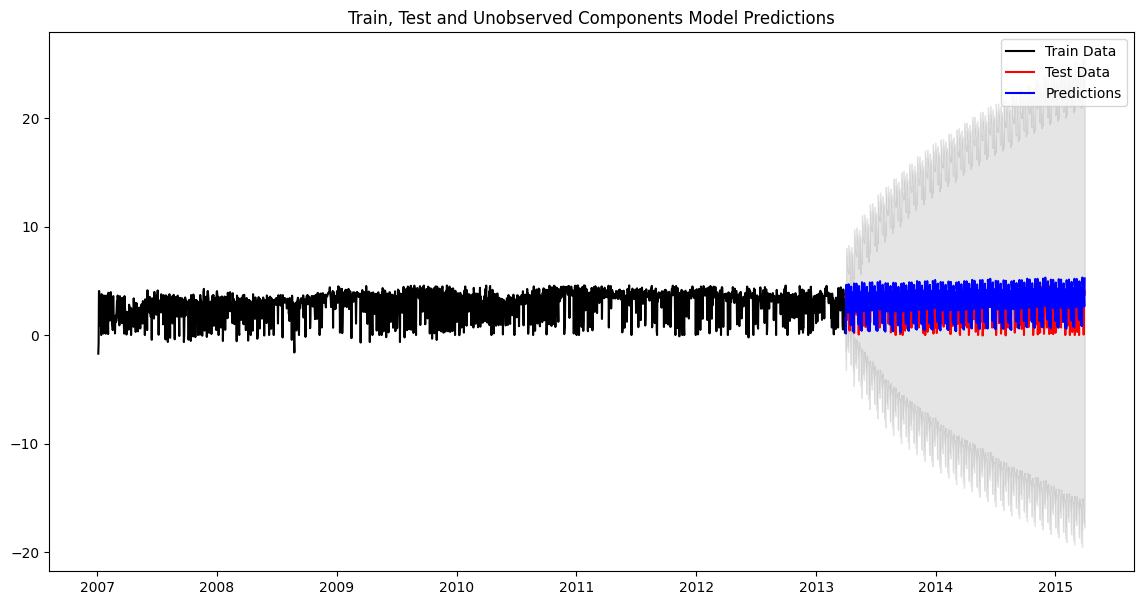

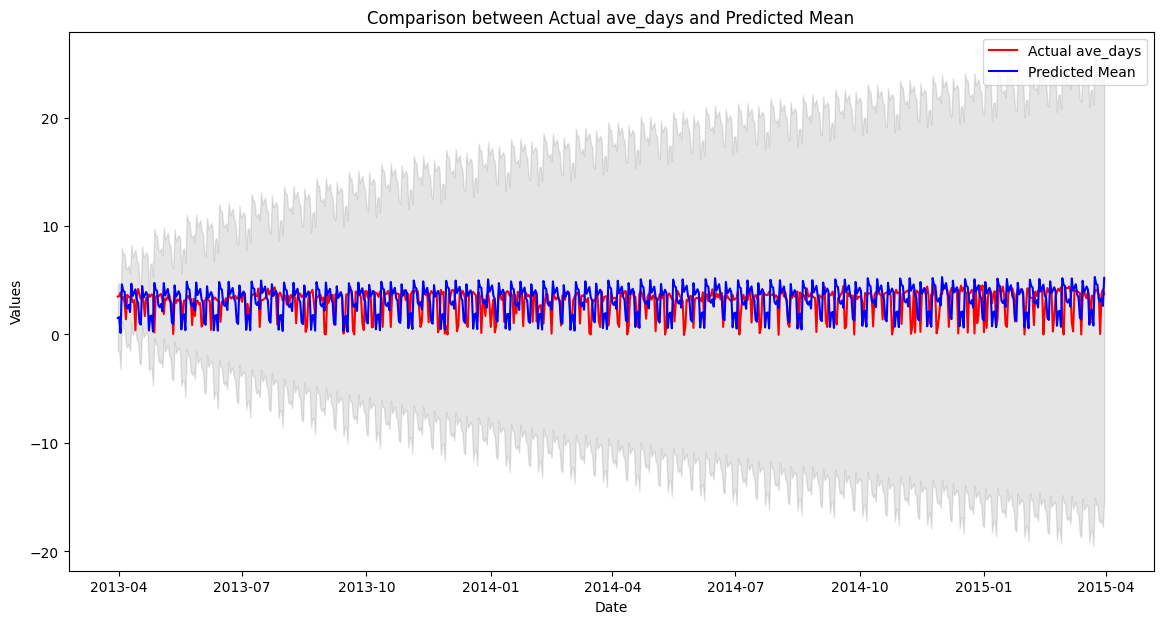

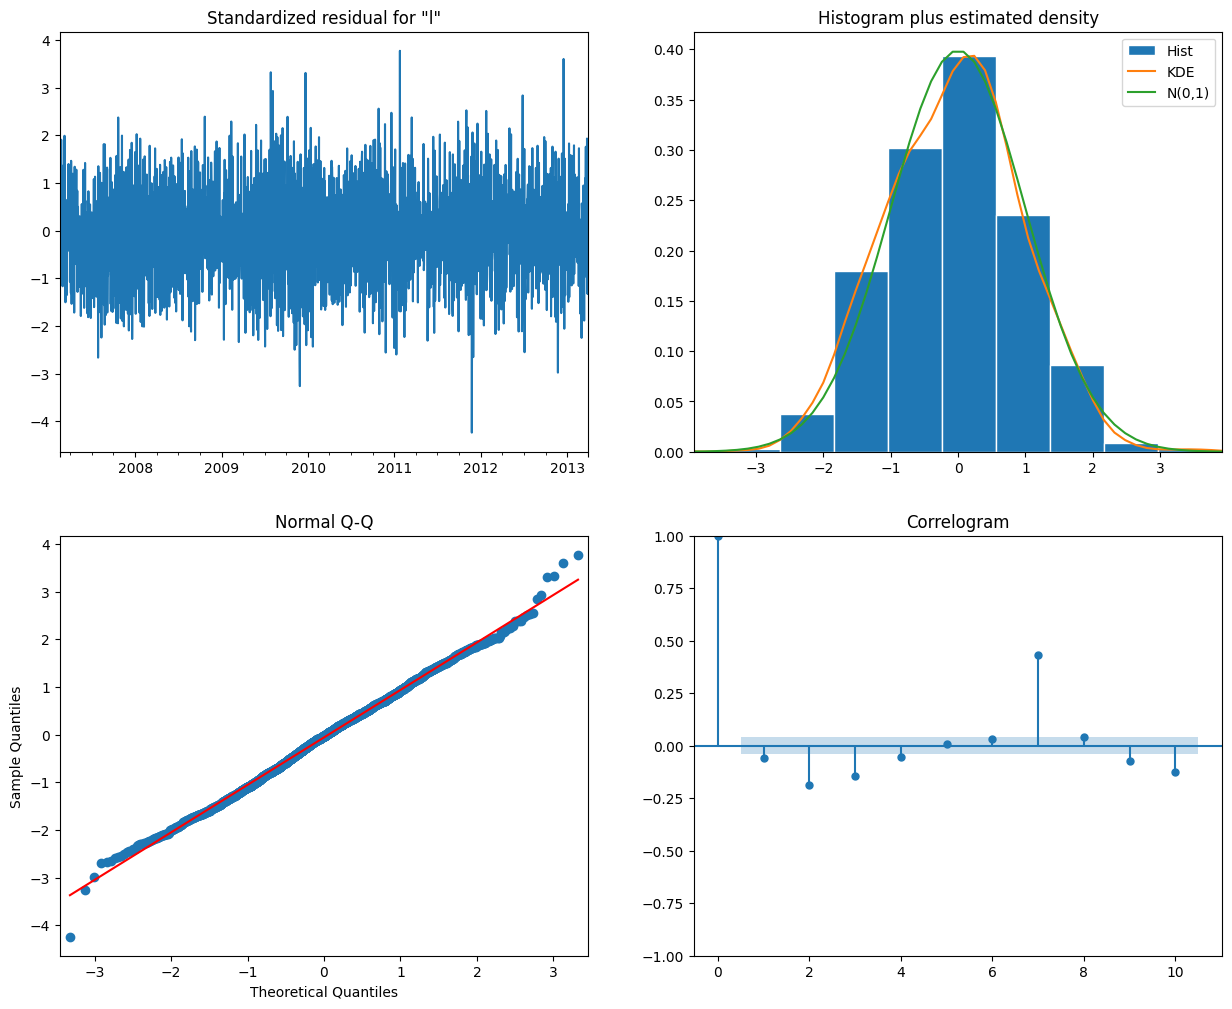

In [ ]:

# from statsmodels.tsa.statespace.structural import UnobservedComponents

# Assuming logtrain_arima and logtest_arima, preprocessed time series data

# Define the UnobservedComponents model with the best parameters found earlier
UCM1 = UnobservedComponents(logtrain_arima,
                            seasonal=24,
                            level='rwdrift',  # the best result from the previous step
                            freq_seasonal=[{'period': 24, 'harmonics': 3},
                                           {'period': 168, 'harmonics': 6}],
                            stochastic_seasonal=True)

mod = UCM1.fit()

# Generate predictions
forecast_results = mod.get_forecast(steps=len(logtest_arima.index))
forecast_mean = forecast_results.predicted_mean
forecast_ci = forecast_results.conf_int(alpha=0.05)

# Set the index for predictions to match the test data
forecast_mean.index = logtest_arima.index
forecast_ci.index = logtest_arima.index

# Calculate MAPE
mape = np.mean(np.abs((logtest_arima - forecast_mean) / logtest_arima)) * 100
print(f'MAPE: {mape:.2f}%')

# Calculate MAE
mae = np.mean(np.abs(logtest_arima - forecast_mean))
print(f'MAE: {mae:.2f}')

# Retrieve AIC
aic = mod.aic
print(f'AIC: {aic:.2f}')

# Plot the results
plt.figure(figsize=(14, 7))
plt.plot(logtrain_arima, color='Black', label='Train Data')
plt.plot(logtest_arima, color='Red', label='Test Data')
plt.plot(forecast_mean, color='Blue', label='Predictions')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='k', alpha=0.1) # confidence interval
plt.legend()
plt.title('Train, Test and Unobserved Components Model Predictions')
plt.show()

# Plot comparison between predicted and actual values
plt.figure(figsize=(14, 7))
plt.plot(logtest_arima.index, logtest_arima, color='Red', label='Actual ave_days')
plt.plot(logtest_arima.index, forecast_mean, color='Blue', label='Predicted Mean')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='k', alpha=0.1) # confidence interval
plt.legend()
plt.title('Comparison between Actual log_ave_days and Predicted Mean')
plt.xlabel('Date')
plt.ylabel('Values')
plt.show()

# Plot diagnostics
mod.plot_diagnostics(figsize=(15, 12))
plt.show()




In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Carry out Ljung-Box test
print(acorr_ljungbox(residuals, return_df=True))


       lb_stat     lb_pvalue
1    42.233701  8.099223e-11
2    49.171836  2.101220e-11
3    77.788844  9.146289e-17
4   184.682138  7.359633e-39
5   247.563661  1.831620e-51
6   248.911065  7.008519e-51
7   408.575254  3.454307e-84
8   447.316063  1.389926e-91
9   458.504621  4.356045e-93
10  462.455661  4.597519e-93


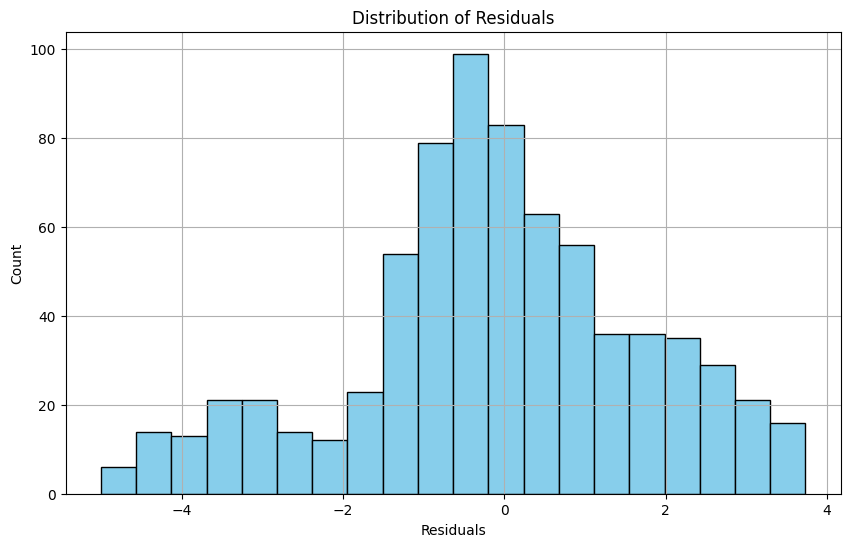

Mean of residuals: -0.12155366878431062


In [ ]:
import matplotlib.pyplot as plt

# Plot histogram of the residuals using Matplotlib
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Count')
plt.grid(True)
plt.show()

# Mean of residuals
print("Mean of residuals:", residuals.mean())


##  the mean of the residuals, which is approximately -0.1216.
#  This value represents the average deviation of the residuals from the predicted values.
#  It generally indicates whether the model tends to overestimate or underestimate
# the observed values, with a mean closer to zero suggesting better predictive accuracy.

## The required forecasting period.


In [ ]:

dates_forecasts = pd.date_range(start='2015-04-01 00:00:00', end='2015-11-07 00:00:00', freq='D')
df_forecasts= pd.DataFrame()
df_forecasts.index = dates_forecasts
# merged_log_train_test df_sdo

In [ ]:
df_forecasts['ave_days'] = None
df_all =  pd.concat([merged_log_train_test, df_forecasts], axis=0)

In [ ]:
df_forecasts

,ave_days
2015-04-01,None
2015-04-02,None
2015-04-03,None
2015-04-04,None
2015-04-05,None
...,...
2015-11-03,None
2015-11-04,None
2015-11-05,None
2015-11-06,None


In [ ]:
df_all

,log_ave_days,ave_days
2007-01-04,-1.717651,NaN
2007-01-05,-0.693147,NaN
2007-01-06,4.052480,NaN
2007-01-07,4.052480,NaN
2007-01-08,1.258955,NaN
...,...,...
2015-11-03,NaN,None
2015-11-04,NaN,None
2015-11-05,NaN,None
2015-11-06,NaN,None


In [ ]:
mod1 = UnobservedComponents(merged_log_train_test,
                                seasonal = 28,
                                level = 'rwdrift',  # quello che si è ottenuto come risultato migliore nel passo precedente
                                freq_seasonal = [{'period': 24, 'harmonics': 3},
                                                 {'period': 168, 'harmonics': 6}],
                                stochastic_seasonal=True)
mod = mod1.fit()

pred = mod.forecast(steps=len(df_forecasts))
preds = pd.Series(pred, index=df_forecasts.index)

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


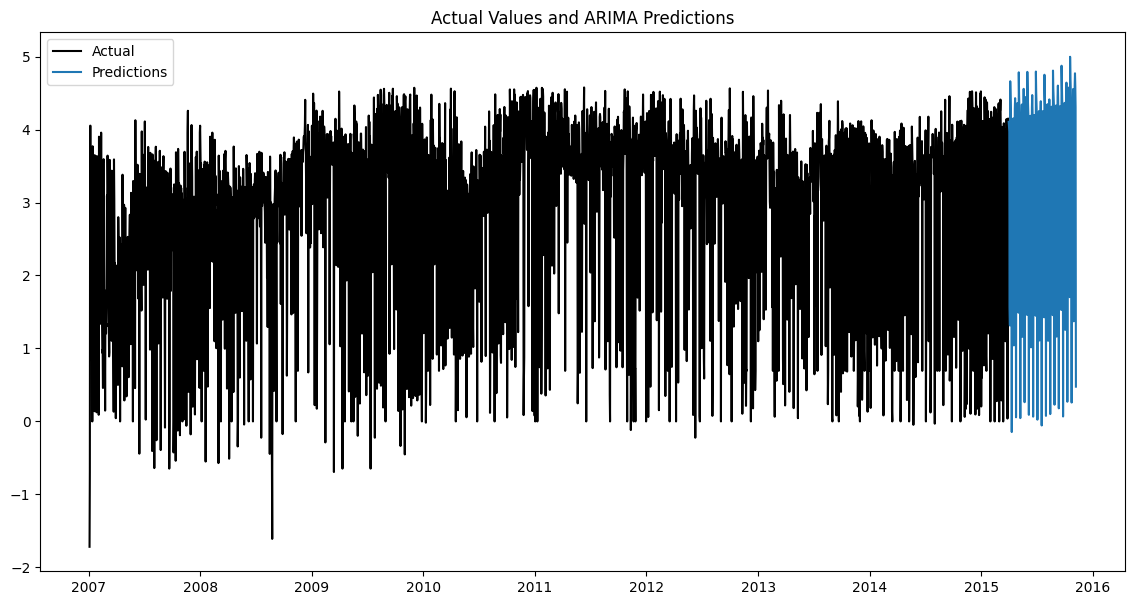

In [ ]:
# Plot the results
plt.figure(figsize=(14, 7))
plt.plot(merged_log_train_test, color='Black', label='Actual')
# plt.plot(logtest_arima, color='Red', label='Test Data')
# plt.plot(y_pred_out, color='Blue', label='ARIMA Predictions')
plt.plot(preds, label='Predictions')
plt.legend()
plt.title('Actual Values and ARIMA Predictions')
plt.show()

In [ ]:
mod2 = UnobservedComponents(merged_log_train_test,
                                seasonal = 24,
                                level = 'rwdrift',  # quello che si è ottenuto come risultato migliore nel passo precedente
                                freq_seasonal = [{'period': 24, 'harmonics': 3},
                                                 {'period': 168, 'harmonics': 6}],
                                stochastic_seasonal=True)
mod2 = mod2.fit()

pred2 = mod2.forecast(steps=len(df_forecasts))
preds2 = pd.Series(pred2, index=df_forecasts.index)

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


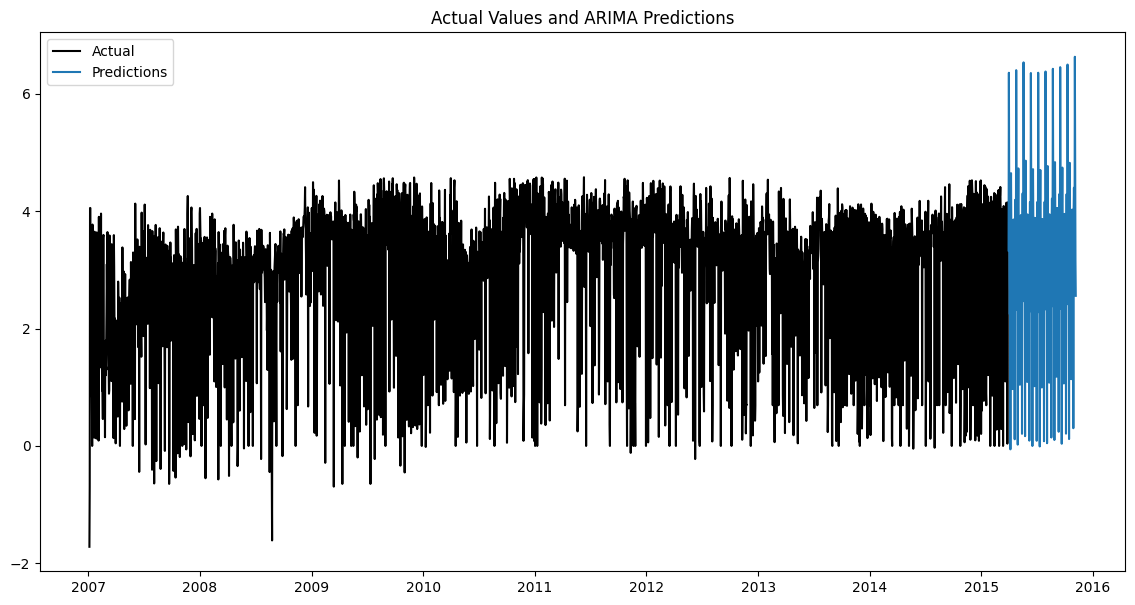

In [ ]:
# Plot the results
plt.figure(figsize=(14, 7))
plt.plot(merged_log_train_test, color='Black', label='Actual')
# plt.plot(logtest_arima, color='Red', label='Test Data')
# plt.plot(y_pred_out, color='Blue', label='ARIMA Predictions')
plt.plot(preds2, label='Predictions')
plt.legend()
plt.title('Actual Values and ARIMA Predictions')
plt.show()

# The preds of the best performing model

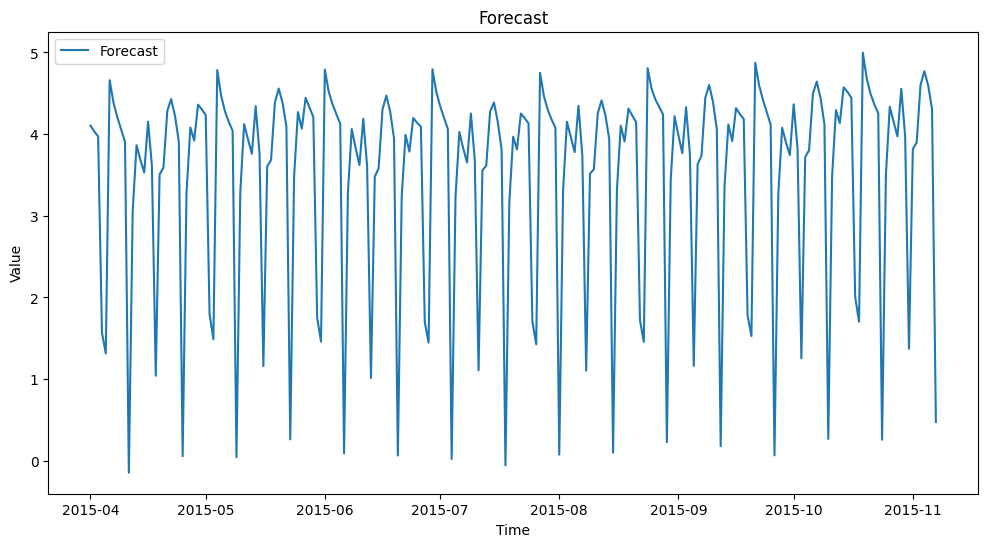

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(preds, label='Forecast')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Forecast')
plt.legend()
plt.show()

In [ ]:
# # saving the results of the arima model
Pred_results['UCM'] = preds.values


In [ ]:
Pred_results.to_csv('Pred_resultsA.csv')
# dfPred_resultsA = pd.read_csv('Pred_resultsA.csv')

In [ ]:
# dfPred_resultsA = pd.read_csv('Pred_resultsA.csv')
# dfPred_resultsA

,Unnamed: 0,Date,ARIMA,UCM,ML
0,0,2015-04-01,3.866467,4.105594,NaN
1,1,2015-04-02,4.136905,4.032670,NaN
2,2,2015-04-03,4.152169,3.972032,NaN
3,3,2015-04-04,0.933657,1.568789,NaN
4,4,2015-04-05,0.919669,1.314595,NaN
...,...,...,...,...,...
216,216,2015-11-03,4.008872,4.601171,NaN
217,217,2015-11-04,4.456024,4.770505,NaN
218,218,2015-11-05,3.987833,4.595374,NaN
219,219,2015-11-06,3.678108,4.306950,NaN


## ML

In [ ]:

dfone = pd.read_csv('train.csv')
dfone.head()


,date,weekday,ave_days
0,2007-01-04,Thursday,0.179487
1,2007-01-05,Friday,0.500000
2,2007-01-06,Saturday,NaN
3,2007-01-07,Sunday,NaN
4,2007-01-08,Monday,3.521739


In [ ]:
dfnew = dfone.dropna()

In [ ]:
import pandas as pd

def new_features(df, label):
    df = dfnew.copy()
    df['date'] = pd.to_datetime(df['date'])  # Convert 'date' column to datetime type
    df['dayofweek'] = df['date'].dt.dayofweek
    df['quarter'] = df['date'].dt.quarter
    df['dayofmonth'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter
    df['year'] = df['date'].dt.year
    df['Day_of_year'] = df['date'].dt.dayofyear
    df['Weekend'] = df['date'].dt.weekday.isin([5, 6]).astype(int)
    #df['weekofyear'] = df['date'].dt.weekofyear
    X = df.drop(label, axis=1)
    y = df[label]
    return X, y

In [ ]:
dff = df.copy()
dff

,date,weekday,ave_days
date,,,
2007-01-04,2007-01-04,Thursday,0.179487
2007-01-05,2007-01-05,Friday,0.500000
2007-01-06,2007-01-06,Saturday,57.539966
2007-01-07,2007-01-07,Sunday,57.539966
2007-01-08,2007-01-08,Monday,3.521739
...,...,...,...
2015-03-27,2015-03-27,Friday,38.580756
2015-03-28,2015-03-28,Saturday,1.040000
2015-03-29,2015-03-29,Sunday,42.000000


In [ ]:
# Example usage
X, y = new_features(dff, label='ave_days')
dff = pd.concat([X, y], axis=1)
dff.head()

,date,weekday,dayofweek,quarter,dayofmonth,month,year,Day_of_year,Weekend,ave_days
0,2007-01-04,Thursday,3,1,4,1,2007,4,0,0.179487
1,2007-01-05,Friday,4,1,5,1,2007,5,0,0.500000
4,2007-01-08,Monday,0,1,8,1,2007,8,0,3.521739
5,2007-01-09,Tuesday,1,1,9,1,2007,9,0,2.850000
6,2007-01-10,Wednesday,2,1,10,1,2007,10,0,2.333333


In [ ]:
# Drop the 'rolmean' column
dff = dff.drop(columns=['weekday','date'])

In [ ]:
# Function to map month to season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

# Add season column to the dataframe
dff['season'] = dff['month'].apply(get_season)

# Display the dataframe with the added season column
# print(df)


In [ ]:
# Function to map month to season
def get_season(month):
    if month in [12, 1, 2]:
        return 0  # Winter
    elif month in [3, 4, 5]:
        return 1  # Spring
    elif month in [6, 7, 8]:
        return 2  # Summer
    else:
        return 3  # Autumn

# Add season column to the dataframe
dff['season'] = dff['month'].apply(get_season)

# Display the dataframe with the added season column
# print(df)


In [ ]:
dff1 = dff.copy()

In [ ]:
# Reorder the columns
dff1 = dff1[['dayofweek', 'quarter', 'dayofmonth','Day_of_year', 'month', 'Weekend', 'season', 'year', 'ave_days']]
dff1

,dayofweek,quarter,dayofmonth,Day_of_year,month,Weekend,season,year,ave_days
0,3,1,4,4,1,0,0,2007,0.179487
1,4,1,5,5,1,0,0,2007,0.500000
4,0,1,8,8,1,0,0,2007,3.521739
5,1,1,9,9,1,0,0,2007,2.850000
6,2,1,10,10,1,0,0,2007,2.333333
...,...,...,...,...,...,...,...,...,...
3004,4,1,27,86,3,0,1,2015,38.580756
3005,5,1,28,87,3,1,1,2015,1.040000
3006,6,1,29,88,3,1,1,2015,42.000000
3007,0,1,30,89,3,0,1,2015,63.477124


In [ ]:
dff1.duplicated().sum()

0

In [ ]:
from sklearn.model_selection import train_test_split

# Preparing data for training and testing
X = dff1.drop('ave_days', axis=1)
y = dff1['ave_days']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Printing train and test set size
print(f'Train set size: {len(X_train)}')
print(f'Test set size: {len(X_test)}')



Train set size: 2245
Test set size: 562


In [ ]:
X_train

,dayofweek,quarter,dayofmonth,Day_of_year,month,Weekend,season,year
1283,5,3,10,191,7,1,2,2010
492,5,2,10,131,5,1,1,2008
1885,5,1,3,63,3,1,1,2012
2877,3,4,20,324,11,0,3,2014
2462,1,4,1,274,10,0,3,2013
...,...,...,...,...,...,...,...,...
829,6,2,12,102,4,1,1,2009
902,2,2,24,175,6,0,2,2009
1768,0,4,7,311,11,0,3,2011
2791,1,3,26,238,8,0,2,2014


In [ ]:

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# from sklearn.metrics import mean_absolute_error

In [ ]:

def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Training model
    model.fit(X_train, y_train)

    # Prediction on test set
    predictions = model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)

    # Calculate MAPE
    absolute_errors = np.abs(y_test - predictions)
    denominator = np.abs(y_test)
    denominator[denominator == 0] = 1  # Set zero values to 1 to avoid division by zero
    percentage_errors = absolute_errors / denominator

#     Calculate MAPE
    mape = percentage_errors.mean()

    # Printing metrics
    print(f'Root Mean Squared Error: {rmse}')
    print(f'Mean Absolute Error: {mae}')
    print(f'Mean Absolute Percentage Error: {mape:.2f}%')

    return rmse, mae, mape

# Choosing different ML models
# models = [
#     RandomForestRegressor(n_estimators=100, random_state=42),
# #    LinearRegression(),
# #     GradientBoostingRegressor(n_estimators=100, random_state=42),
#     DecisionTreeRegressor(random_state=42),
#     SVR(kernel='rbf'),  # Support Vector Regressor
# #     XGBRegressor()  # XGBoost Regressor
# ]

# # Models comparison
# for model in models:
#     print(f'\nEvaluating {model.__class__.__name__}:\n')
#     evaluate_model(model, X_train, y_train, X_test, y_test)

In [ ]:
from sklearn.svm import SVR

# Choosing different ML models
models = [
    RandomForestRegressor(n_estimators=100, random_state=42),
    LinearRegression(),
    GradientBoostingRegressor(n_estimators=100, random_state=42),
    DecisionTreeRegressor(random_state=42),
    SVR(kernel='rbf')  # Using RBF kernel, you can change the kernel as needed
]

# Models comparison
for model in models:
    print(f'\nEvaluating {model.__class__.__name__}:\n')
    evaluate_model(model, X_train, y_train, X_test, y_test)


Evaluating RandomForestRegressor:

Root Mean Squared Error: 43.369881580592605
Mean Absolute Error: 17.94509444301774
Mean Absolute Percentage Error: 2.41%

Evaluating LinearRegression:

Root Mean Squared Error: 46.44594815278047
Mean Absolute Error: 22.109186014779056
Mean Absolute Percentage Error: 3.29%

Evaluating GradientBoostingRegressor:

Root Mean Squared Error: 44.47211004774755
Mean Absolute Error: 18.302018434725674
Mean Absolute Percentage Error: 2.33%

Evaluating DecisionTreeRegressor:

Root Mean Squared Error: 52.531179966583316
Mean Absolute Error: 21.044954292410015
Mean Absolute Percentage Error: 2.42%

Evaluating SVR:

Root Mean Squared Error: 48.22033367923373
Mean Absolute Error: 24.176060117770916
Mean Absolute Percentage Error: 3.84%


In [ ]:
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [ ]:


# Choosing different ML models
models = [
    RandomForestRegressor(n_estimators=100, random_state=42),
    LinearRegression(),
    GradientBoostingRegressor(n_estimators=100, random_state=42),
    DecisionTreeRegressor(random_state=42),
    SVR(kernel='rbf')  # Using RBF kernel, you can change the kernel as needed
]

# Models comparison
for model in models:
    print(f'\nEvaluating {model.__class__.__name__}:\n')
    evaluate_model(model, X_train, y_train, X_test, y_test)


Evaluating RandomForestRegressor:

Root Mean Squared Error: 43.369881580592605
Mean Absolute Error: 17.94509444301774
Mean Absolute Percentage Error: 2.41%

Evaluating LinearRegression:

Root Mean Squared Error: 46.44594815278047
Mean Absolute Error: 22.109186014779056
Mean Absolute Percentage Error: 3.29%

Evaluating GradientBoostingRegressor:

Root Mean Squared Error: 44.47211004774755
Mean Absolute Error: 18.302018434725674
Mean Absolute Percentage Error: 2.33%

Evaluating DecisionTreeRegressor:

Root Mean Squared Error: 52.531179966583316
Mean Absolute Error: 21.044954292410015
Mean Absolute Percentage Error: 2.42%

Evaluating SVR:

Root Mean Squared Error: 48.22033367923373
Mean Absolute Error: 24.176060117770916
Mean Absolute Percentage Error: 3.84%


In [ ]:
# Based on these metrics, the GradientBoostingRegressor model has the lowest RMSE (44.47)
# and the lowest MAE (18.30), indicating that it performs the best among the models evaluated.
# It also has a relatively low MAPE (2.33%), which is desirable. Therefore, the GradientBoostingRegressor
# model may be considered the best choice for this particular problem.

In [ ]:
# Training the selected model (GradientBoostingRegressor)
modelgb = GradientBoostingRegressor(n_estimators=100, random_state=42)
modelgb.fit(X_train, y_train)

# Computing again prediction on test set for visualization
test_predictions = modelgb.predict(X_test)

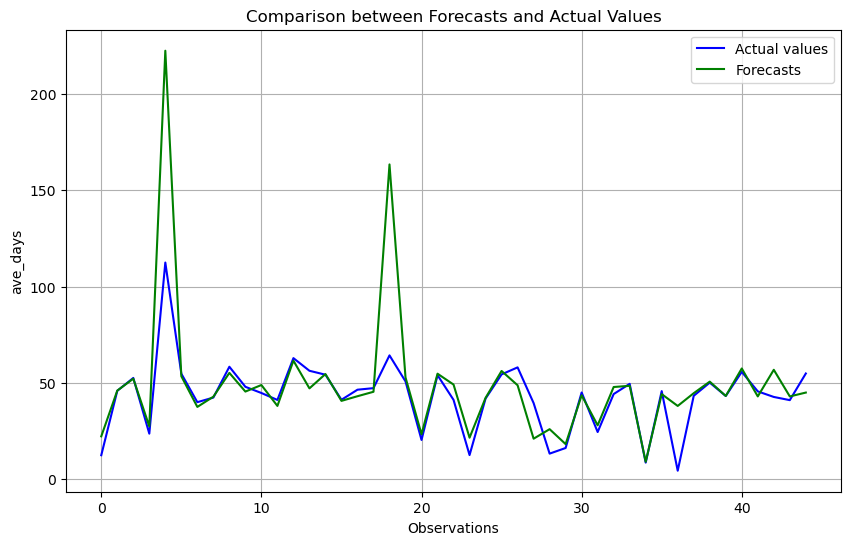

In [ ]:
# Plotting some values for visual comparison
plt.figure(figsize=(10, 6))
plt.plot(y_test.values[0:100], label='Actual values', linestyle='-', color='b')
plt.plot(test_predictions[0:100], label='Forecasts', linestyle='-', color='g')

plt.title('Comparison between Forecasts and Actual Values')
plt.xlabel('Observations')
plt.ylabel('ave_days')
plt.legend()
plt.grid(True)
# Saving plot
plt.savefig('ML_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Training the selected model (Random Forest Regressor)
models = RandomForestRegressor(n_estimators=100, random_state=42)
models.fit(X_train, y_train)

# Computing again prediction on test set for visualization
test_predictions = models.predict(X_test)

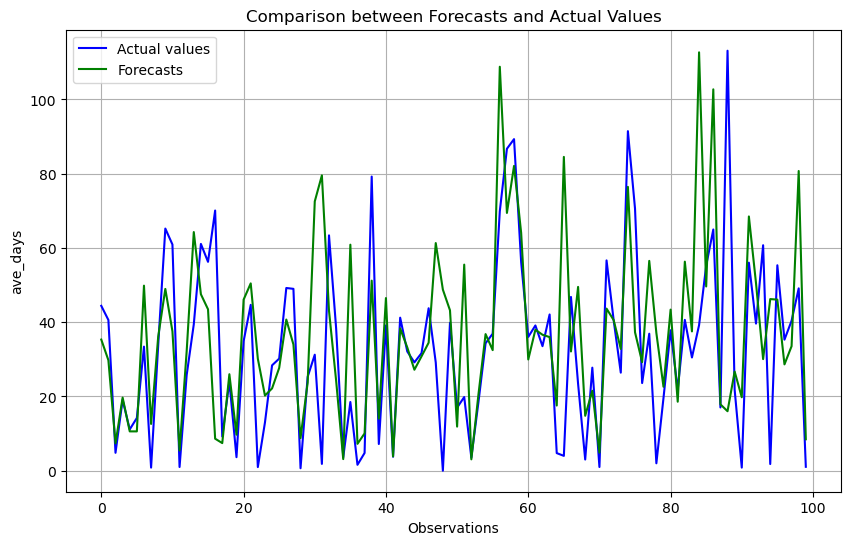

In [ ]:
# Plotting some values for visual comparison
plt.figure(figsize=(10, 6))
plt.plot(y_test.values[0:100], label='Actual values', linestyle='-', color='b')
plt.plot(test_predictions[0:100], label='Forecasts', linestyle='-', color='g')

plt.title('Comparison between Forecasts and Actual Values')
plt.xlabel('Observations')
plt.ylabel('ave_days')
plt.legend()
plt.grid(True)
# Saving plot
plt.savefig('ML_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
forecast_date = pd.date_range(start='2015-04-01', end='2015-11-07', freq='d')
forecast_date


DatetimeIndex(['2015-04-01', '2015-04-02', '2015-04-03', '2015-04-04',
               '2015-04-05', '2015-04-06', '2015-04-07', '2015-04-08',
               '2015-04-09', '2015-04-10',
               ...
               '2015-10-29', '2015-10-30', '2015-10-31', '2015-11-01',
               '2015-11-02', '2015-11-03', '2015-11-04', '2015-11-05',
               '2015-11-06', '2015-11-07'],
              dtype='datetime64[ns]', length=221, freq='D')

In [ ]:
# dayofweek	quarter	dayofmonth	Day_of_year	month	Weekend	season	year



# Defining date input format 2015-04-01 through 2015-11-07.
date_format = "%Y-%m-%d"

# Starting date
start_date = datetime(2015, 4, 1)
end_date = datetime(2015, 11, 7)
num_days = (end_date - start_date).days + 1  # Adding 1 to include the end date

# Creating date range with only year, month, and date
timestamps = [start_date + timedelta(days=i) for i in range(num_days)]

# Creating december dataframe for future predictions
december_data = {
    'date': timestamps,
}

forecast_df = pd.DataFrame(december_data)

forecast_df['date'] = pd.to_datetime(forecast_df['date'])  # Convert 'date' column to datetime type
forecast_df['dayofweek'] = forecast_df['date'].dt.dayofweek
forecast_df['quarter'] = forecast_df['date'].dt.quarter
forecast_df['dayofmonth'] = forecast_df['date'].dt.day
forecast_df['month'] = forecast_df['date'].dt.month
# forecast_df['quarter'] = forecast_df['date'].dt.quarter
forecast_df['year'] = forecast_df['date'].dt.year
forecast_df['Day_of_year'] = forecast_df['date'].dt.dayofyear
forecast_df['Weekend'] = forecast_df['date'].dt.weekday.isin([5, 6]).astype(int)
# forecast_df['Day_of_year'] = forecast_df['date'].dt.dayofyear
# forecast_df['Weekend'] = forecast_df['date'].dt.weekday.isin([5, 6]).astype(int)

forecast_df = forecast_df.drop('date', axis=1)

# Displaying the december dataframe
forecast_df


,dayofweek,quarter,dayofmonth,month,year,Day_of_year,Weekend
0,2,2,1,4,2015,91,0
1,3,2,2,4,2015,92,0
2,4,2,3,4,2015,93,0
3,5,2,4,4,2015,94,1
4,6,2,5,4,2015,95,1
...,...,...,...,...,...,...,...
216,1,4,3,11,2015,307,0
217,2,4,4,11,2015,308,0
218,3,4,5,11,2015,309,0
219,4,4,6,11,2015,310,0


In [ ]:
# Function to map month to season
def get_season(month):
    if month in [12, 1, 2]:
        return 0  # Winter
    elif month in [3, 4, 5]:
        return 1  # Spring
    elif month in [6, 7, 8]:
        return 2  # Summer
    else:
        return 3  # Autumn

# Add season column to the dataframe
forecast_df['season'] = forecast_df['month'].apply(get_season)

In [ ]:
desired_columns_order = ['dayofweek', 'quarter', 'dayofmonth', 'Day_of_year', 'month', 'Weekend', 'season', 'year']

# Reindex the DataFrame to match the desired order of columns
forecast_df = forecast_df.reindex(columns=desired_columns_order)

# Print the ordered DataFrame
print(forecast_df)

     dayofweek  quarter  dayofmonth  Day_of_year  month  Weekend  season  year
0            2        2           1           91      4        0       1  2015
1            3        2           2           92      4        0       1  2015
2            4        2           3           93      4        0       1  2015
3            5        2           4           94      4        1       1  2015
4            6        2           5           95      4        1       1  2015
..         ...      ...         ...          ...    ...      ...     ...   ...
216          1        4           3          307     11        0       3  2015
217          2        4           4          308     11        0       3  2015
218          3        4           5          309     11        0       3  2015
219          4        4           6          310     11        0       3  2015
220          5        4           7          311     11        1       3  2015

[221 rows x 8 columns]


In [ ]:
# Adding predictions to forecast_df
forecast_df_predictions = models.predict(forecast_df)
forecast_df['ML_Predictions'] = forecast_df_predictions
forecast_df

,dayofweek,quarter,dayofmonth,Day_of_year,month,Weekend,season,year,ML_Predictions
0,2,2,1,91,4,0,1,2015,53.183486
1,3,2,2,92,4,0,1,2015,62.829483
2,4,2,3,93,4,0,1,2015,50.608651
3,5,2,4,94,4,1,1,2015,7.061094
4,6,2,5,95,4,1,1,2015,38.847183
...,...,...,...,...,...,...,...,...,...
216,1,4,3,307,11,0,3,2015,47.127876
217,2,4,4,308,11,0,3,2015,49.436408
218,3,4,5,309,11,0,3,2015,54.455206
219,4,4,6,310,11,0,3,2015,48.564568


In [ ]:
X = forecast_df.drop('ML_Predictions', axis=1)
y = forecast_df['ML_Predictions']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Printing train and test set size
print(f'Train set size: {len(X_train)}')
print(f'Test set size: {len(X_test)}')

Train set size: 176
Test set size: 45


In [ ]:
model = GradientBoostingRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

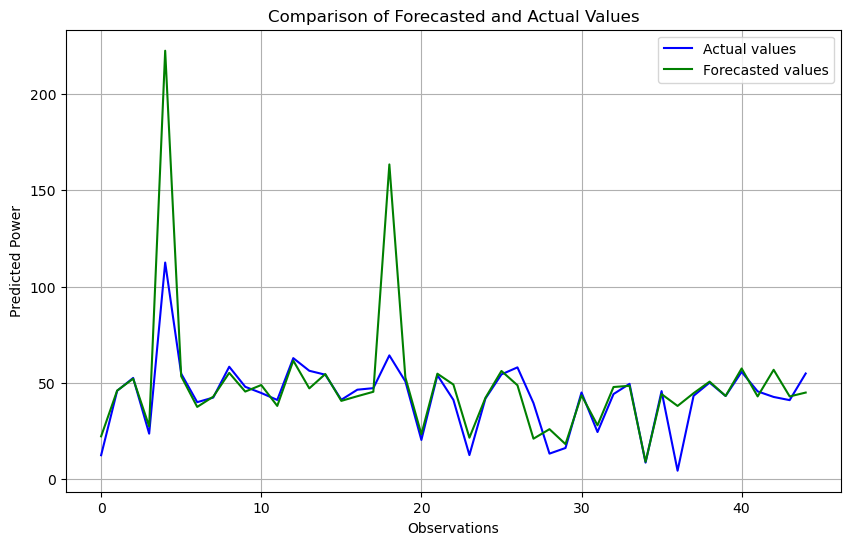

In [ ]:
# Generating predictions on the test set for visualization
test_predictions = model.predict(X_test)

# Visualizing a subset of actual and forecasted values
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plotting actual values
plt.plot(y_test.values[0:100], label='Actual values', linestyle='-', color='b')

# Plotting forecasted values
plt.plot(test_predictions[0:100], label='Forecasted values', linestyle='-', color='g')

# Adding title and axis labels
plt.title('Comparison of Forecasted and Actual Values')
plt.xlabel('Observations')
plt.ylabel('Predicted Values')

# Adding legend and grid
plt.legend()
plt.grid(True)

# Saving the plot
plt.savefig('ML_predictions.png', dpi=300, bbox_inches='tight')

# Displaying the plot
plt.show()


In [ ]:
# Assuming you have a DataFrame called forecast_df containing 'year', 'month', and 'dayofmonth' columns
forecast_data = forecast_df.rename(columns={'dayofmonth': 'day'})
forecast_data

,dayofweek,quarter,day,Day_of_year,month,Weekend,season,year,ML_Predictions
0,2,2,1,91,4,0,1,2015,53.183486
1,3,2,2,92,4,0,1,2015,62.829483
2,4,2,3,93,4,0,1,2015,50.608651
3,5,2,4,94,4,1,1,2015,7.061094
4,6,2,5,95,4,1,1,2015,38.847183
...,...,...,...,...,...,...,...,...,...
216,1,4,3,307,11,0,3,2015,47.127876
217,2,4,4,308,11,0,3,2015,49.436408
218,3,4,5,309,11,0,3,2015,54.455206
219,4,4,6,310,11,0,3,2015,48.564568


In [ ]:
# Assuming you have a DataFrame called forecast_df containing 'year', 'month', and 'dayofmonth' columns
forecast_data['date'] = pd.to_datetime(forecast_data[['year', 'month', 'day']])

# Drop the individual date components columns
forecast_data = forecast_data.drop(['year', 'month', 'day'], axis=1)

# Convert 'date' column to the desired format "%Y-%m-%d"
forecast_data['date'] = forecast_data['date'].dt.strftime("%Y-%m-%d")


In [ ]:
forecast_data['date'] = pd.to_datetime(forecast_data['date'])
forecast_data

,dayofweek,quarter,Day_of_year,Weekend,season,ML_Predictions,date
0,2,2,91,0,1,53.183486,2015-04-01
1,3,2,92,0,1,62.829483,2015-04-02
2,4,2,93,0,1,50.608651,2015-04-03
3,5,2,94,1,1,7.061094,2015-04-04
4,6,2,95,1,1,38.847183,2015-04-05
...,...,...,...,...,...,...,...
216,1,4,307,0,3,47.127876,2015-11-03
217,2,4,308,0,3,49.436408,2015-11-04
218,3,4,309,0,3,54.455206,2015-11-05
219,4,4,310,0,3,48.564568,2015-11-06


In [ ]:
_df = forecast_data[['date', 'ML_Predictions']].copy()
_df.set_index('date',inplace= True)

In [ ]:
df.set_index('date',inplace= True)

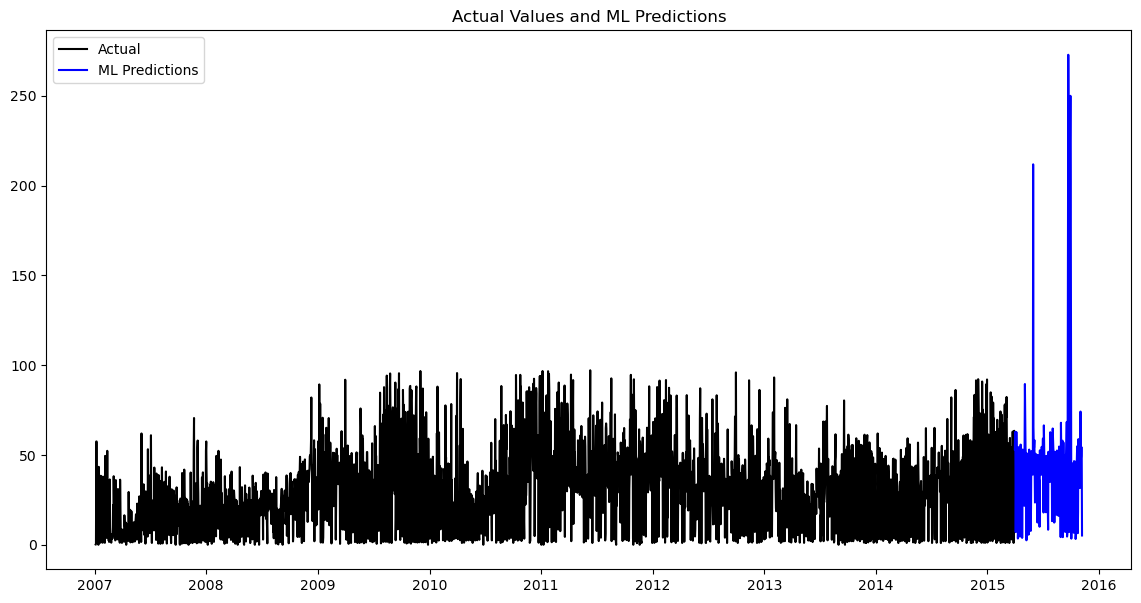

In [ ]:
# Plot the results
plt.figure(figsize=(14, 7))
# plt.plot(merged_log_train_test, color='Black', label='Actual')
# plt.plot(logtest_arima, color='Red', label='Test Data')
# plt.plot(y_pred_out, color='Blue', label='ARIMA Predictions')
plt.plot(df['ave_days'], color='Black', label='Actual')
plt.plot(_df , color='Blue', label='ML Predictions')
plt.legend()
plt.title('Actual Values and ML Predictions')
plt.show()

In [ ]:
Pred_results

,Date,ARIMA,UCM,ML
0,2015-04-01,3.866467,4.105594,NaN
1,2015-04-02,4.136905,4.032670,NaN
2,2015-04-03,4.152169,3.972032,NaN
3,2015-04-04,0.933657,1.568789,NaN
4,2015-04-05,0.919669,1.314595,NaN
...,...,...,...,...
216,2015-11-03,4.008872,4.601171,NaN
217,2015-11-04,4.456024,4.770505,NaN
218,2015-11-05,3.987833,4.595374,NaN
219,2015-11-06,3.678108,4.306950,NaN


In [ ]:
# saving the results of the arima model
Pred_results['ML'] = _df.ML_Predictions.values
Pred_results

,Date,ARIMA,UCM,ML
0,2015-04-01,3.866467,4.105594,53.183486
1,2015-04-02,4.136905,4.032670,62.829483
2,2015-04-03,4.152169,3.972032,50.608651
3,2015-04-04,0.933657,1.568789,7.061094
4,2015-04-05,0.919669,1.314595,38.847183
...,...,...,...,...
216,2015-11-03,4.008872,4.601171,47.127876
217,2015-11-04,4.456024,4.770505,49.436408
218,2015-11-05,3.987833,4.595374,54.455206
219,2015-11-06,3.678108,4.306950,48.564568


In [ ]:

# # Export DataFrame to CSV
# Pred_results.to_csv(file_path, index=False)

Pred_results.to_csv('897683_20240614.csv')
# dfPred_resultsA = pd.read_csv('Pred_resultsA.csv')

In [ ]:
dfPred_resultsA = pd.read_csv('897683_20240218.csv')
dfPred_resultsA

,Unnamed: 0,Date,ARIMA,UCM,ML
0,0,2015-04-01,3.866467,4.105594,53.183486
1,1,2015-04-02,4.136905,4.032670,62.829483
2,2,2015-04-03,4.152169,3.972032,50.608651
3,3,2015-04-04,0.933657,1.568789,7.061094
4,4,2015-04-05,0.919669,1.314595,38.847183
...,...,...,...,...,...
216,216,2015-11-03,4.008872,4.601171,47.127876
217,217,2015-11-04,4.456024,4.770505,49.436408
218,218,2015-11-05,3.987833,4.595374,54.455206
219,219,2015-11-06,3.678108,4.306950,48.564568


In [3]:
# df = pd.read_csv('897683_20240614.csv')

In [4]:
# df

,Unnamed: 0,Date,ARIMA,UCM,ML
0,0,2015-04-01,3.866467,4.105594,53.183486
1,1,2015-04-02,4.136905,4.032670,62.829483
2,2,2015-04-03,4.152169,3.972032,50.608651
3,3,2015-04-04,0.933657,1.568789,7.061094
4,4,2015-04-05,0.919669,1.314595,38.847183
...,...,...,...,...,...
216,216,2015-11-03,4.008872,4.601171,47.127876
217,217,2015-11-04,4.456024,4.770505,49.436408
218,218,2015-11-05,3.987833,4.595374,54.455206
219,219,2015-11-06,3.678108,4.306950,48.564568


In [ ]:
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 13.6 gigabytes of available RAM

Not using a high-RAM runtime
